## Exploratory Data Analysis

In [1]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import warnings
from typing import List, Tuple, Union, Any
from sklearn.metrics import precision_recall_curve, f1_score

# Set style for plots
sns.set_style("whitegrid")
warnings.filterwarnings('ignore') 

# Define custom params for plots
rcParams = {
    'font.size': 20,                # all fonts-size in plot
    'font.weight': 'bold',          # bold all fonts
    'figure.titleweight': 'bold',   # bold supertitle
    'axes.linewidth' : 6,
    'xtick.major.width': 6,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'lines.linewidth': 6,
    'legend.fontsize': 'large',
    'xtick.labelsize': 'large',
    'ytick.labelsize': 'large',
    'xtick.labelsize': 20,   # sets x-tick font size
    'ytick.labelsize': 20,
    'axes.titlepad': 20,   # spacing between suptitle and figure
    'axes.facecolor': 'white'
}

# Update rcparams
mpl.rcParams.update(rcParams) 

### Data understanding and Preparation

In [2]:
# read data
raw_df = pd.read_csv('./raw_data/bank_data.csv', sep = ';')
print(f"Shape of data: {raw_df.shape}")

Shape of data: (41188, 21)


In [3]:
print(f"The number of columns in the data: {raw_df.shape[1]}")
print(f"Column names: {raw_df.columns.values}")

The number of columns in the data: 21
Column names: <StringArray>
[           'age',            'job',        'marital',      'education',
        'default',        'housing',           'loan',        'contact',
          'month',    'day_of_week',       'duration',       'campaign',
          'pdays',       'previous',       'poutcome',   'emp.var.rate',
 'cons.price.idx',  'cons.conf.idx',      'euribor3m',    'nr.employed',
              'y']
Length: 21, dtype: str


##### Bank Client Data Description
1. **age**: Age of the client (numeric).
2. **job**: Type of job (categorical):
   - "admin."
   - "blue-collar"
   - "entrepreneur"
   - "housemaid"
   - "management"
   - "retired"
   - "self-employed"
   - "services"
   - "student"
   - "technician"
   - "unemployed"
   - "unknown"
3. **marital**: Marital status (categorical):
   - "divorced" (includes divorced and widowed)
   - "married"
   - "single"
   - "unknown"
4. **education**: Level of education (categorical):
   - "basic.4y"
   - "basic.6y"
   - "basic.9y"
   - "high.school"
   - "illiterate"
   - "professional.course"
   - "university.degree"
   - "unknown"
5. **default**: Has credit in default? (categorical):
   - "no"
   - "yes"
   - "unknown"
6. **housing**: Has housing loan? (categorical):
   - "no"
   - "yes"
   - "unknown"
7. **loan**: Has personal loan? (categorical):
   - "no"
   - "yes"
   - "unknown"

##### Last Contact of the Current Campaign
8. **contact**: Contact communication type (categorical):
   - "cellular"
   - "telephone"
9. **month**: Last contact month of the year (categorical):
   - "jan", "feb", "mar", ..., "nov", "dec"
10. **day_of_week**: Last contact day of the week (categorical):
    - "mon", "tue", "wed", "thu", "fri"
11. **duration**: Last contact duration in seconds (numeric). 

Note: This attribute highly affects the output target. If `duration=0`, then `y="no"`. This input should only be included for benchmark purposes and should be discarded for realistic predictive models.

##### Other Attributes
12. **campaign**: Number of contacts performed during this campaign and for this client (numeric, includes last contact).
13. **pdays**: Number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted).
14. **previous**: Number of contacts performed before this campaign and for this client (numeric).
15. **poutcome**: Outcome of the previous marketing campaign (categorical):
    - "failure"
    - "nonexistent"
    - "success"

##### Social and Economic Context Attributes
16. **emp.var.rate**: Employment variation rate - quarterly indicator (numeric).
17. **cons.price.idx**: Consumer price index - monthly indicator (numeric).
18. **cons.conf.idx**: Consumer confidence index - monthly indicator (numeric).
19. **euribor3m**: Euribor 3 month rate - daily indicator (numeric).
20. **nr.employed**: Number of employees - quarterly indicator (numeric).

##### Output Variable (Desired Target)
21. **y**: Has the client subscribed to a term deposit? (binary: "yes", "no").


##### Acknowledgments
- The dataset is provided by [A data-driven approach to predict the success of bank telemarketing](http://archive.ics.uci.edu/ml/datasets/Bank+Marketing#).




In [4]:
#Let's rename the target variable to Subscription for better understanding
raw_df.rename(columns = {'y': 'Subscription'}, inplace = True)

# Lets look at the data type of columns and how many null values each column has
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

It shows we have unkown values but not missing values.

For all the features described below, we should drop those with variance close to zero. A variance of zero indicates that the column contains nearly identical values for all observations (rows), providing no useful information for prediction.

In [5]:
# Lets look at numeric features
raw_df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [6]:
#Lets look at categorical features
raw_df.describe(include = 'object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,Subscription
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


Now, we'll break down the categorical feautures and count how many times each category appears in each categorical feautures

In [7]:
def get_category_cols_info(df):
    # Store data into a dictionary
    value_counts_dict = {}
    percentage_dict = {}

    # Get categorical columns
    categorical_columns = df.select_dtypes(include=['object']).columns

    # Get the value counts and percentages of each category for a given categorical column
    for col in categorical_columns:
        counts = df[col].value_counts()
        percentages = df[col].value_counts(normalize=True) * 100
        value_counts_dict[col] = counts.to_dict()
        percentage_dict[col] = percentages.to_dict()

    # Convert the dictionaries to DataFrames
    counts_df = pd.DataFrame.from_dict(value_counts_dict, orient='index').stack().reset_index()
    percentages_df = pd.DataFrame.from_dict(percentage_dict, orient='index').stack().reset_index()

    # Rename the columns for clarity
    counts_df.columns = ['Category', 'Value', 'Count']
    percentages_df.columns = ['Category', 'Value', 'Percentage']

    # Merge the counts and percentages DataFrames
    merged_df = pd.merge(counts_df, percentages_df, on=['Category', 'Value'])

    # Set MultiIndex
    merged_df.set_index(['Category', 'Value'], inplace=True)

    return merged_df

In [8]:
# show the category counts of each column
pd.set_option('display.max_rows', None)
print(get_category_cols_info(raw_df).dropna())

                                    Count  Percentage
Category     Value                                   
job          admin.               10422.0   25.303486
             blue-collar           9254.0   22.467709
             technician            6743.0   16.371273
             services              3969.0    9.636302
             management            2924.0    7.099155
             retired               1720.0    4.175974
             entrepreneur          1456.0    3.535010
             self-employed         1421.0    3.450034
             housemaid             1060.0    2.573565
             unemployed            1014.0    2.461882
             student                875.0    2.124405
             unknown                330.0    0.801204
marital      unknown                 80.0    0.194231
             married              24928.0   60.522482
             single               11568.0   28.085850
             divorced              4612.0   11.197436
education    unknown        

### Customer Segmentation Analysis

#### Demographic Segmentation

These features describe who the customer is in terms of personal attributes such as age, occupation, marital status and education level.

- **Age** (`age`): Key demographic indicator of life stage and potential financial behavior.
- **Job** (`job`): Can indicate income levels and financial stability.
- **Marital** (`marital`): Marital status influences financial priorities and consumption patterns.
- **Education** (`education`): Helps gauge financial literacy and potentially financial habits.


<Axes: xlabel='count', ylabel='loan'>

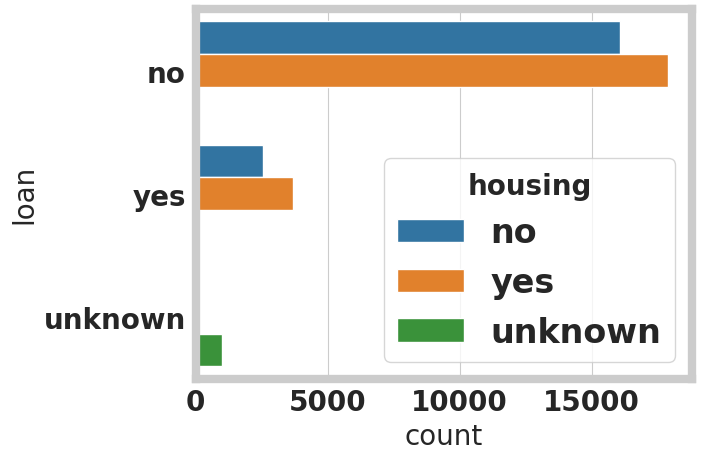

In [9]:
sns.countplot(raw_df, y = 'loan', hue = 'housing')

In [10]:
def plot_counts_and_normalized_counts(data: pd.DataFrame, column: str, target:str = 'Subscription' , 
    figsize: tuple = (16, 8), show_counts_table: bool = True) -> None:
    """
    Plots counts and normalized counts of a specified column with a hue.

    Parameters:
    - data (pd.DataFrame): The DataFrame containing the data.
    - column (str): The categorical column to plot counts and normalized counts for.
    - target (str): The categorical target column.
    - figsize (tuple): The size of the figure (default is (16, 8)).

    Returns:
    - None: Displays the plot with counts and normalized counts.
    """
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = figsize, sharey = True)

    # Group by the specified column and hue, and count occurrences
    counts = data.groupby([column, target]).size().sort_values(ascending = False).reset_index(name ='target_counts')

    # Calculate the total counts for each hue category
    total_counts = data.groupby(column).size().sort_values(ascending = False).reset_index(name = 'total_category_counts')

    # Merge the total counts with the counts
    counts = counts.merge(total_counts, on = column)

    if show_counts_table:
        print(counts)

    # Calculate the normalized counts
    counts['normalized_counts'] = counts['target_counts'] * 100.0/ counts['total_category_counts']

    # Plot using sns.barplot()
    sns.barplot(data=counts, y = column, x = 'target_counts', hue = target, ax = ax1)
    sns.barplot(data=counts, y=column, x = 'normalized_counts', hue = target, legend = False, ax = ax2)

    # Adjust layout and labels
    plt.tight_layout()
    ax1.set_ylabel(None)
    ax2.set_ylabel(None)

    # Hide all spines for both subplots
    for ax in [ax1, ax2]:
        for spine in ax.spines.values():
            spine.set_visible(False)

    # Set title and labels
    ax1.set_xlabel("Category Counts", fontdict={'weight': 'bold'})
    ax2.set_xlabel("Category Subscription Percentage", fontdict={'weight': 'bold'})
    plt.suptitle(f"Counts and Percentage of Subscription for each Category in {column.capitalize()}")
    plt.subplots_adjust(top = 0.92)

    # Add legend to ax1
    ax1.legend(labelcolor='linecolor', title = target , loc = 'lower right')

    plt.show()


In [11]:
def plot_numeric_distribution(data: pd.DataFrame, column: str, target:str = 'Subscription', 
    multiple:str = 'stack', kde: bool = True, figsize: tuple = (16, 8)) -> None:
    """
    Plots histogram and normalized histogram of a specified column with a hue.

    Parameters:
    - data (pd.DataFrame): The DataFrame containing the data.
    - column (str): The numerical column to histogram and normalized histogram for.
    - target (str): The categorical target column which is used as hue.
    - multiple (str): Specifies how multiple histograms are arranged (default 'stack').Other
    options are 'dodge', 'layer' and 'fill'.
    - kde (bool): Whether to plot kde on top of histogram (default True).
    - figsize (tuple): The size of the figure (default is (16, 8)).

    Returns:
    - None: Displays the plot with hostogram and normalized histogram for numeric column.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 8), sharey = True)


    sns.histplot(data = data, y = column, hue = target, kde = kde, legend = False,
                alpha=0.6, multiple = multiple, ax = ax1)

    # Normalize histogram independently for each type of Subscription
    sns.histplot(data = data, y = column, hue = target, kde = kde, alpha=0.6,
                multiple=multiple, stat='percent', common_norm=False, ax=ax2)

    plt.tight_layout()

    # Hide all spines for both subplots
    for ax in [ax1, ax2]:
        for spine in ax.spines.values():
            spine.set_visible(False)

   # Set title and labels
    ax1.set_ylabel(column.capitalize(), fontdict={'weight': 'bold'})
    ax1.set_xlabel("Subscription Counts", fontdict={'weight': 'bold'})
    ax2.set_xlabel("Subscription Percentage", fontdict={'weight': 'bold'})
   

    plt.suptitle(f"Distribution of Counts and Percentage of Normalized Subscription for {column.capitalize()}")
    plt.subplots_adjust(top = 0.92)
    plt.show()

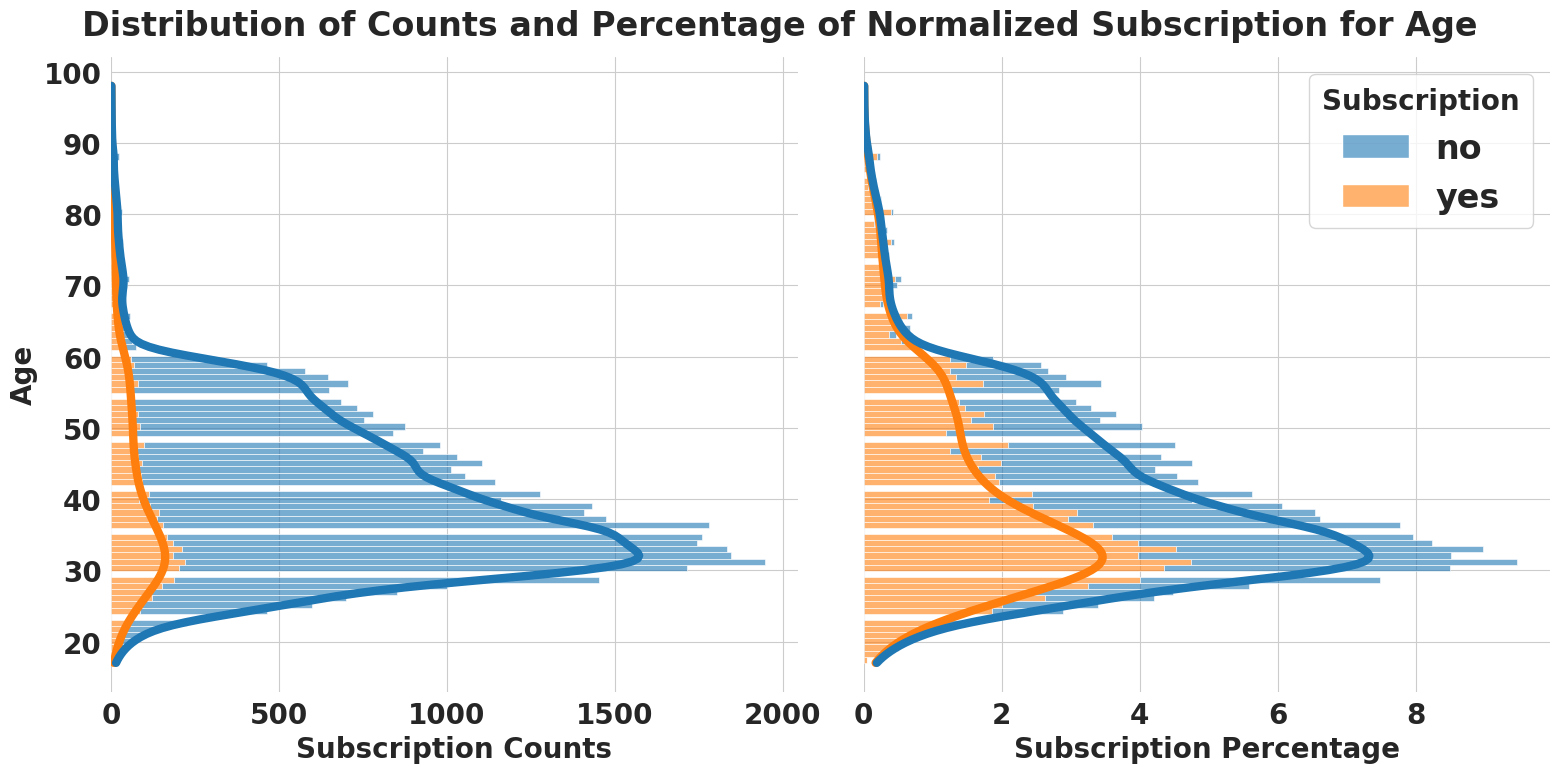

In [12]:
plot_numeric_distribution(raw_df, column = 'age')

              job Subscription  target_counts  total_category_counts
0          admin.           no           9070                  10422
1     blue-collar           no           8616                   9254
2      technician           no           6013                   6743
3        services           no           3646                   3969
4      management           no           2596                   2924
5          admin.          yes           1352                  10422
6    entrepreneur           no           1332                   1456
7         retired           no           1286                   1720
8   self-employed           no           1272                   1421
9       housemaid           no            954                   1060
10     unemployed           no            870                   1014
11     technician          yes            730                   6743
12    blue-collar          yes            638                   9254
13        student           no    

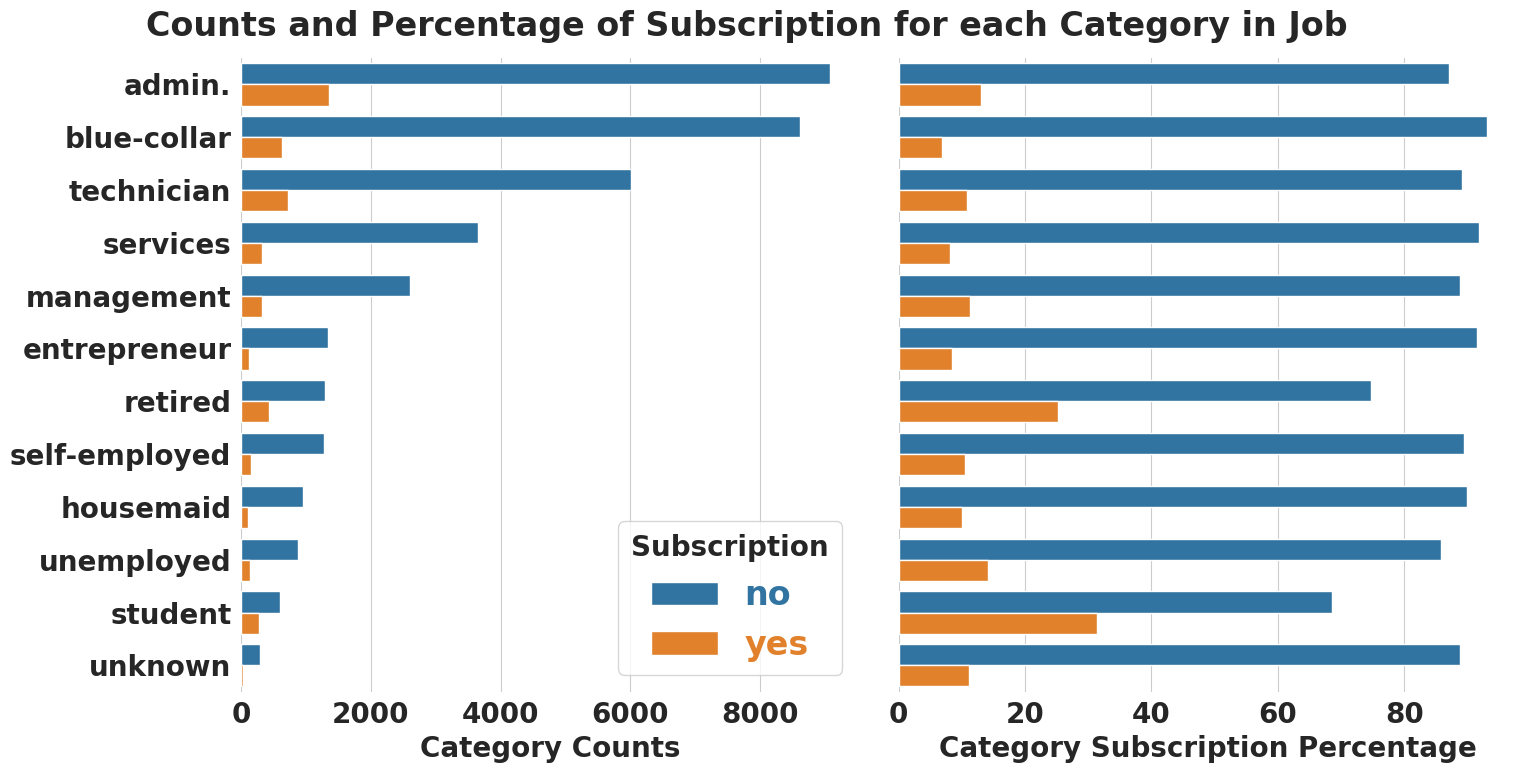

In [13]:
plot_counts_and_normalized_counts(raw_df, column = 'job')

    marital Subscription  target_counts  total_category_counts
0   married           no          22396                  24928
1    single           no           9948                  11568
2  divorced           no           4136                   4612
3   married          yes           2532                  24928
4    single          yes           1620                  11568
5  divorced          yes            476                   4612
6   unknown           no             68                     80
7   unknown          yes             12                     80


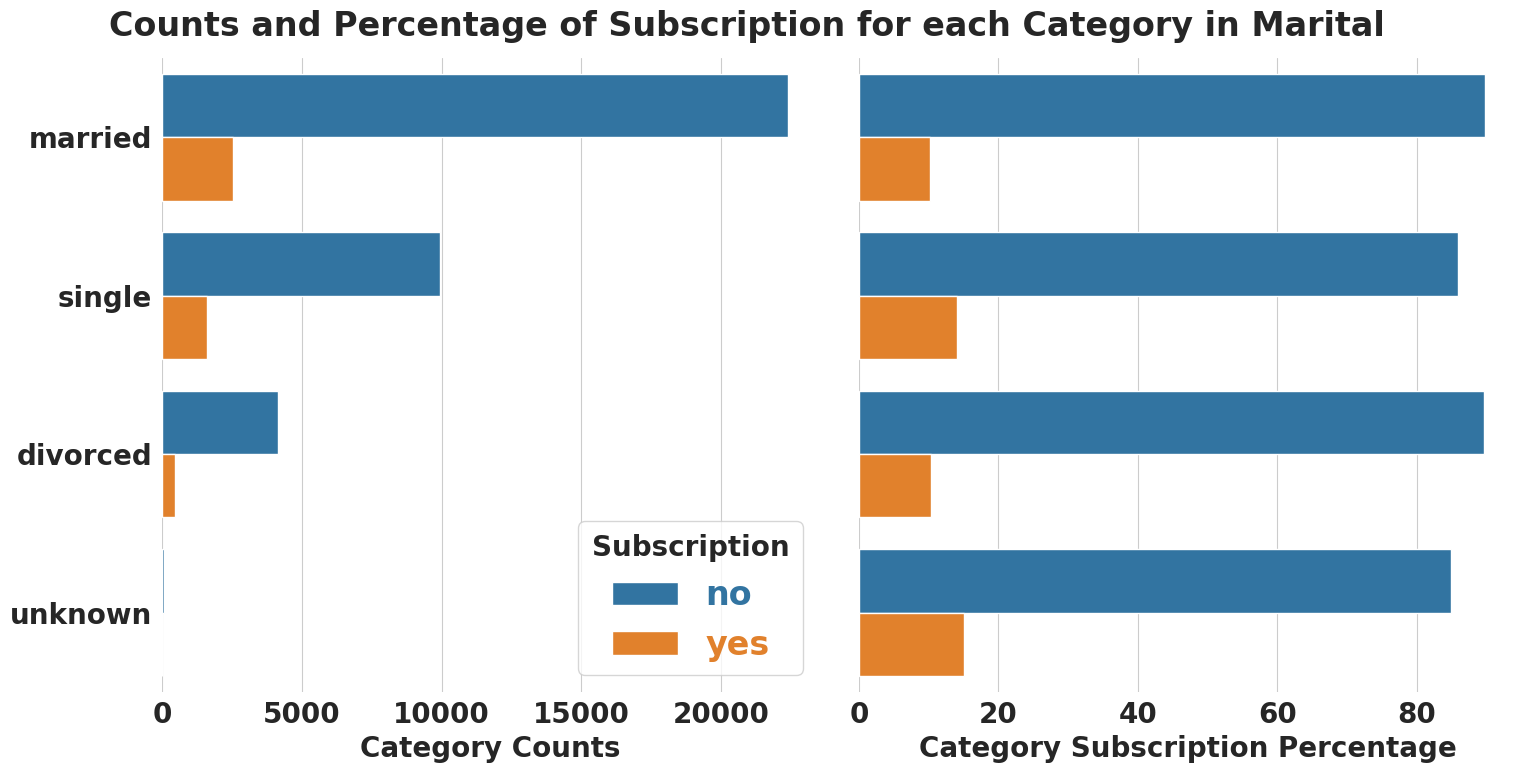

In [14]:
plot_counts_and_normalized_counts(raw_df, column = 'marital')

              education Subscription  target_counts  total_category_counts
0     university.degree           no          10498                  12168
1           high.school           no           8484                   9515
2              basic.9y           no           5572                   6045
3   professional.course           no           4648                   5243
4              basic.4y           no           3748                   4176
5              basic.6y           no           2104                   2292
6     university.degree          yes           1670                  12168
7               unknown           no           1480                   1731
8           high.school          yes           1031                   9515
9   professional.course          yes            595                   5243
10             basic.9y          yes            473                   6045
11             basic.4y          yes            428                   4176
12              unknown  

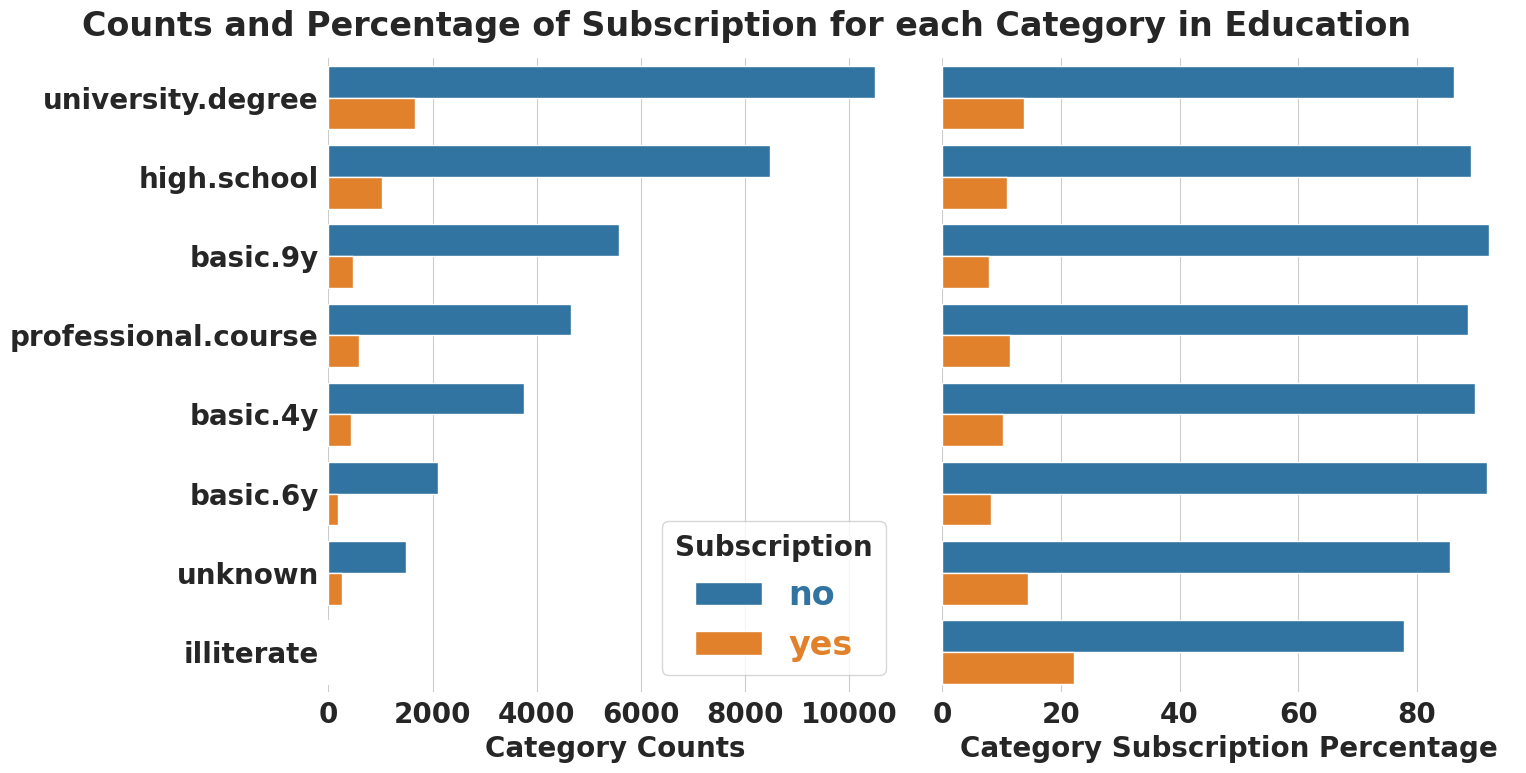

In [15]:
plot_counts_and_normalized_counts(raw_df, column = 'education')

#### Behaviroal Segmentation

These features describe how the customer behaves in terms of financial behavior, response to campaigns, and interaction with financial products.

- **Default** (`default`): Indicates financial reliability and risk behavior.
- **Housing** (`housing`): Whether the customer has a mortgage can indicate long-term financial commitments.
- **Loan** (`loan`): Presence of a personal loan suggests borrowing behavior.
- **Poutcome** (`poutcome`): Outcome of the previous marketing campaign; indicates the customer’s past engagement and response.
- **Campaign** (`campaign`): Shows engagement with marketing efforts, indicating responsiveness.
- **Pdays** (`pdays`): Days since the last contact—could indicate recency of interaction.
- **Previous** (`previous`): Number of previous contacts, showing historical interaction with the customer.

duration -> when do customers are likely to interact more? (month, day of week etc)


default     no  unknown  yes
housing                     
no       14614     4006    2
unknown    763      227    0
yes      17211     4364    1


<Axes: xlabel='count', ylabel='housing'>

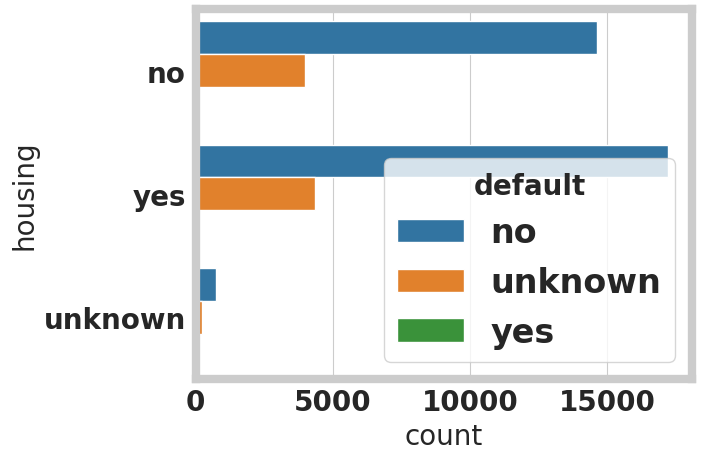

In [16]:
print(pd.crosstab(raw_df['housing'], raw_df['default']))
sns.countplot(raw_df, y = 'housing', hue = 'default')

   default Subscription  target_counts  total_category_counts
0       no           no          28391                  32588
1  unknown           no           8154                   8597
2       no          yes           4197                  32588
3  unknown          yes            443                   8597
4      yes           no              3                      3


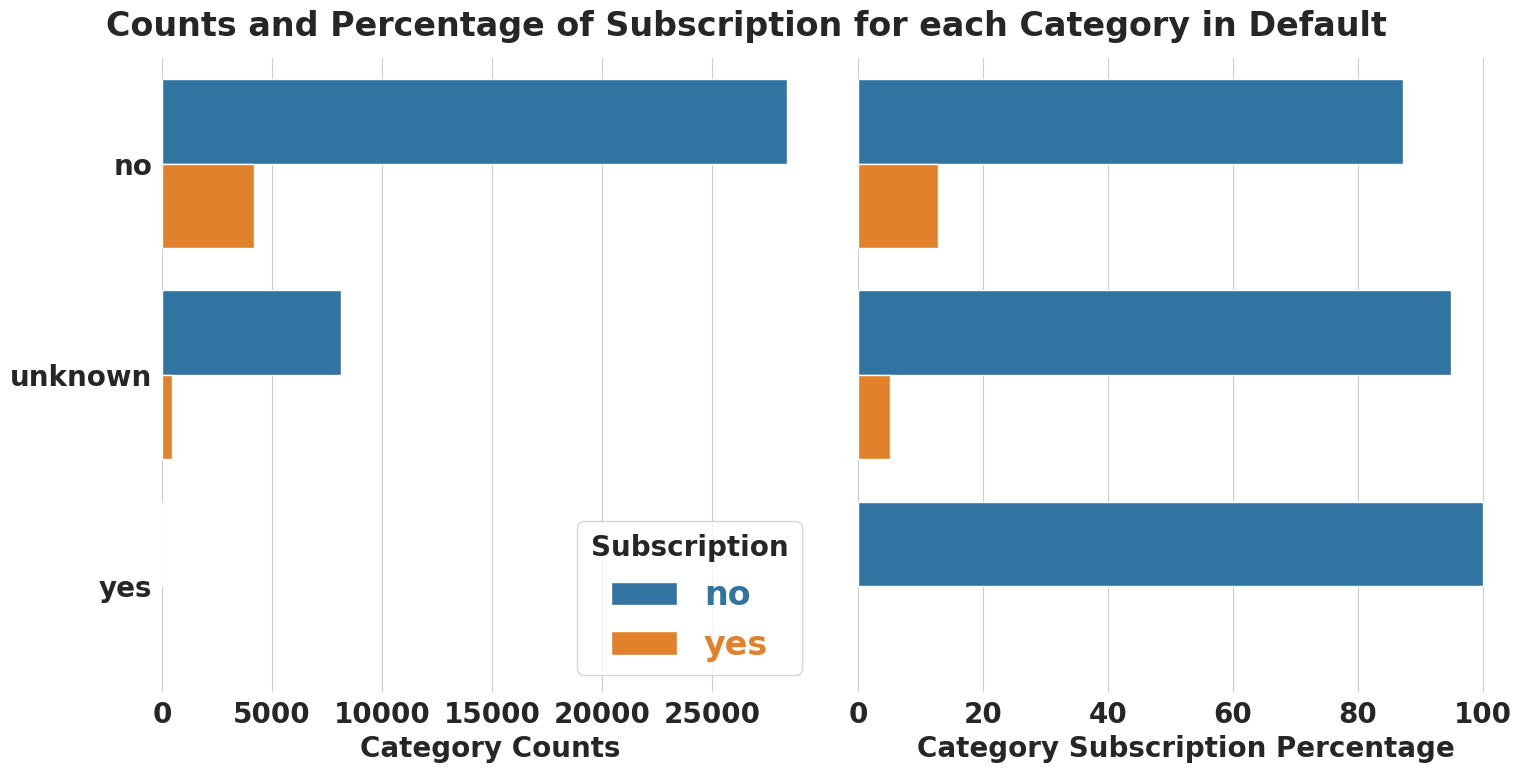

In [17]:
plot_counts_and_normalized_counts(data = raw_df, column = 'default')

   housing Subscription  target_counts  total_category_counts
0      yes           no          19069                  21576
1       no           no          16596                  18622
2      yes          yes           2507                  21576
3       no          yes           2026                  18622
4  unknown           no            883                    990
5  unknown          yes            107                    990


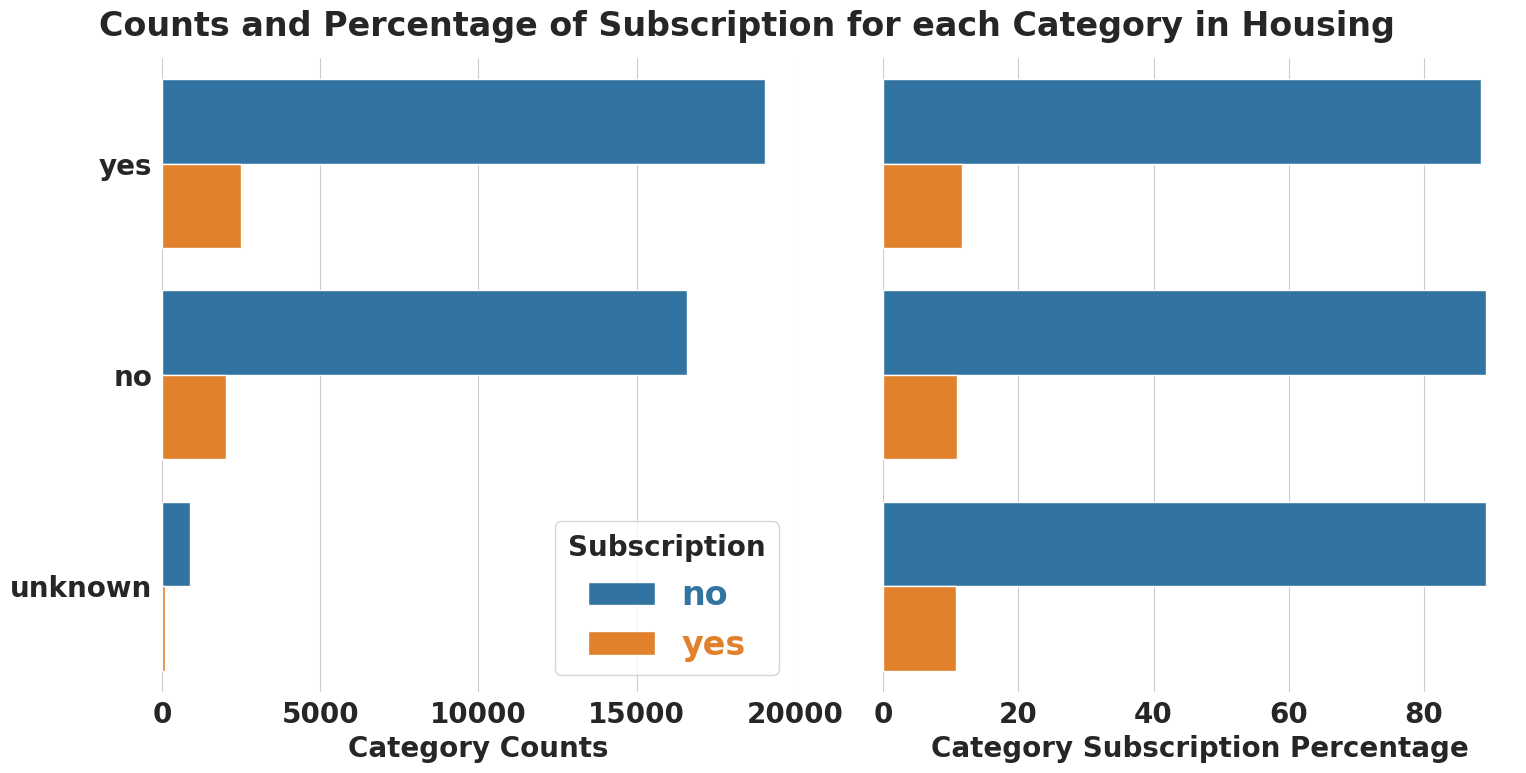

In [18]:
plot_counts_and_normalized_counts(data = raw_df, column = 'housing')

      loan Subscription  target_counts  total_category_counts
0       no           no          30100                  33950
1      yes           no           5565                   6248
2       no          yes           3850                  33950
3  unknown           no            883                    990
4      yes          yes            683                   6248
5  unknown          yes            107                    990


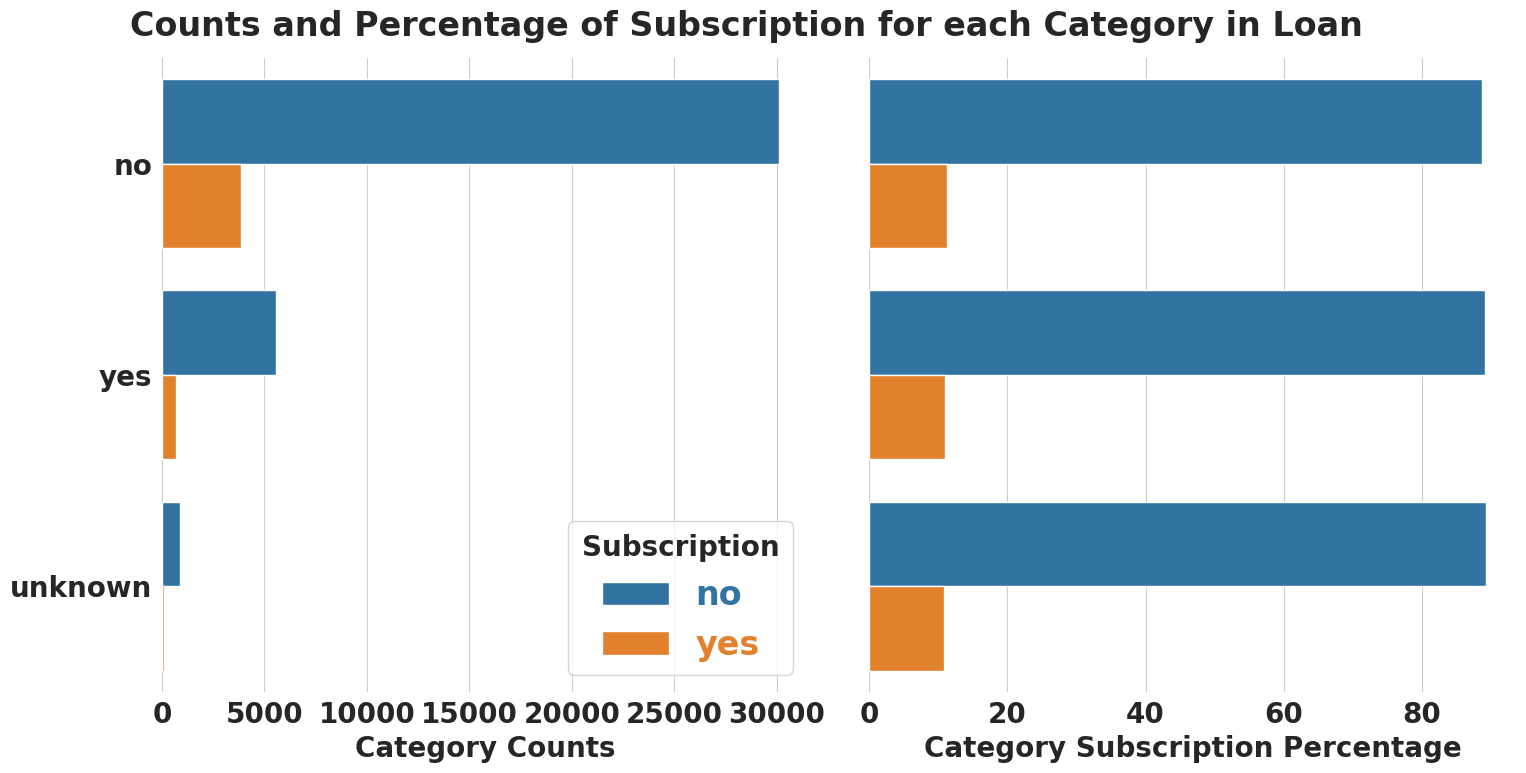

In [19]:
plot_counts_and_normalized_counts(data = raw_df, column = 'loan')

      poutcome Subscription  target_counts  total_category_counts
0  nonexistent           no          32422                  35563
1      failure           no           3647                   4252
2  nonexistent          yes           3141                  35563
3      success          yes            894                   1373
4      failure          yes            605                   4252
5      success           no            479                   1373


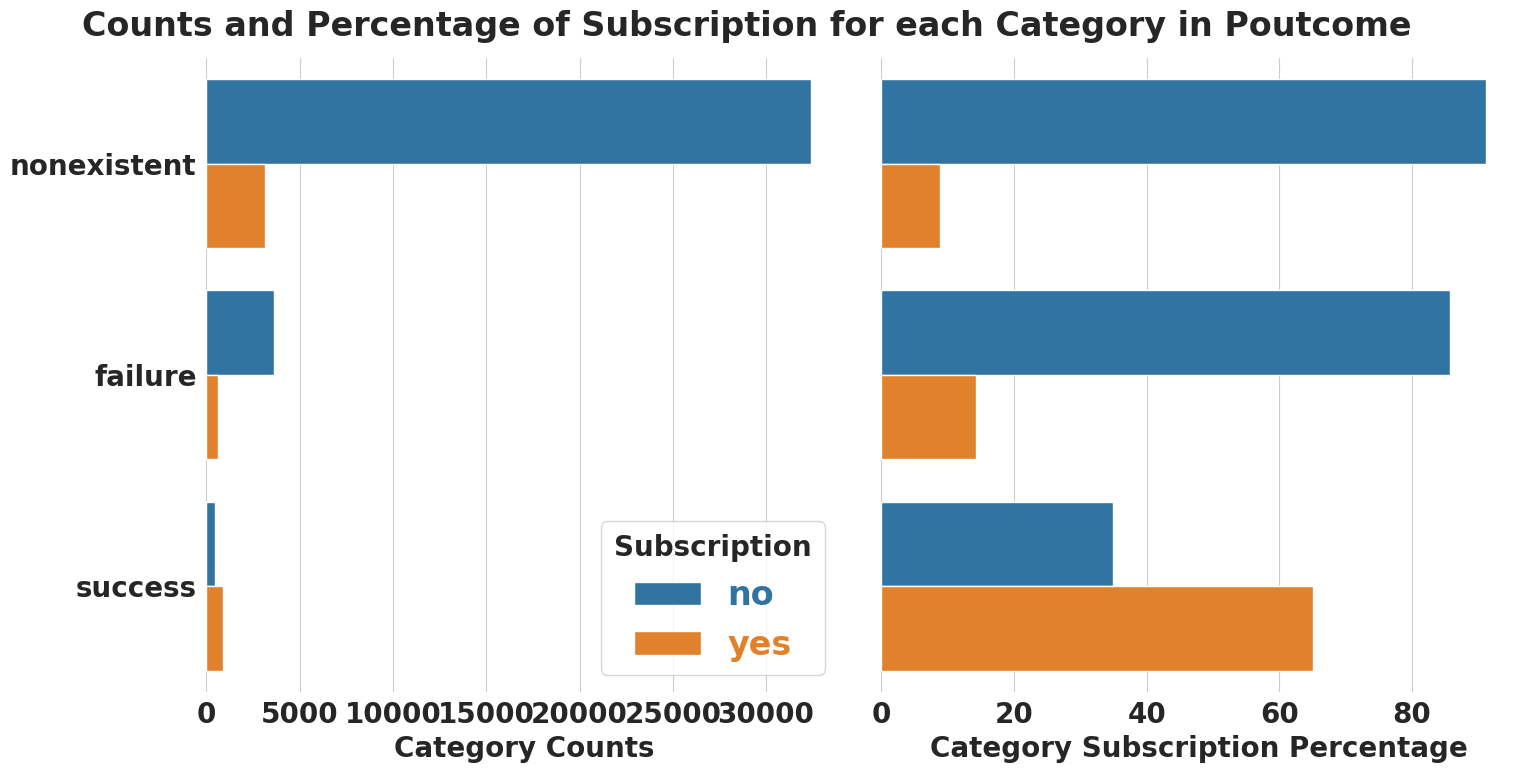

In [20]:
plot_counts_and_normalized_counts(data = raw_df, column = 'poutcome')

Subscription     no   yes  percentage_yes
campaign                                 
1             15342  2300       13.037071
2              9359  1211       11.456954
3              4767   574       10.747051
4              2402   249        9.392682
5              1479   120        7.504690
6               904    75        7.660878
7               591    38        6.041335
8               383    17        4.250000
9               266    17        6.007067
10              213    12        5.333333
11              165    12        6.779661
12              122     3        2.400000
13               88     4        4.347826
14               68     1        1.449275
15               49     2        3.921569
16               51     0        0.000000
17               54     4        6.896552
18               33     0        0.000000
19               26     0        0.000000
20               30     0        0.000000
21               24     0        0.000000
22               17     0        0

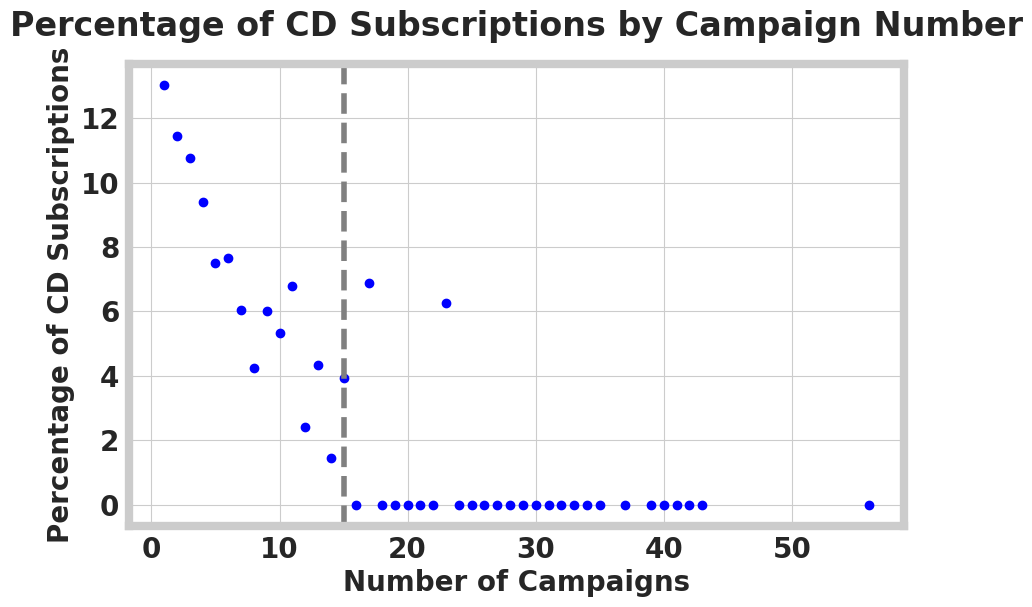

In [21]:
# since the campaign counts for larger than 10 campaign attempts are small
# lets see how the percentage of subscription success changes with campaign attempts

# Calculate the percentage of 'yes' subscriptions for each campaign number
campaign_counts = raw_df.groupby(['campaign', 'Subscription']).size().unstack(fill_value=0)
campaign_counts['percentage_yes'] = campaign_counts['yes'] / (campaign_counts['yes'] + campaign_counts['no']) * 100
print(campaign_counts)

# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(campaign_counts.index, campaign_counts['percentage_yes'], color='blue')
plt.axvline(15, linestyle = '--', color = 'gray', linewidth = 4.0)
plt.xlabel('Number of Campaigns', fontdict = {'weight': 'bold'})
plt.ylabel("Percentage of CD Subscriptions", fontdict = {'weight': 'bold'})
plt.title("Percentage of CD Subscriptions by Campaign Number", fontdict = {'weight': 'bold'})
plt.show()


## Binary Classification Model Selection

### Handling Outliers

In [22]:
# Lets create a copy of raw_df
df = raw_df.copy(deep = True)

print(df.shape)

(41188, 21)


In [23]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [24]:
def inspect_numerical_outliers(df):
    numeric_cols = df.select_dtypes(include = 'number').columns
    for col in numeric_cols:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        sns.boxplot(data=df, x=col, ax=ax1)
        sns.histplot(data=df, x=col, ax=ax2)
        plt.tight_layout()
        plt.show()

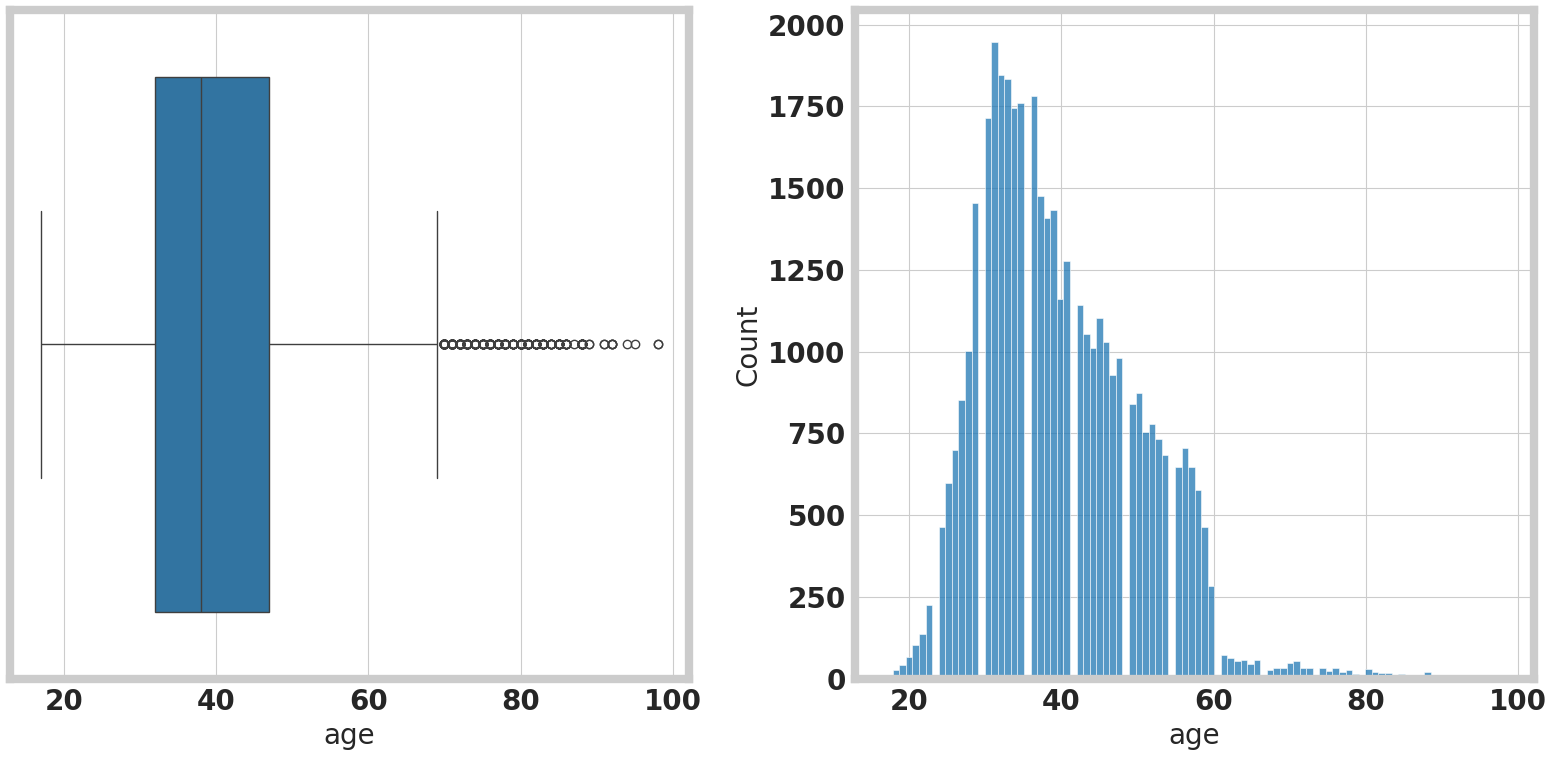

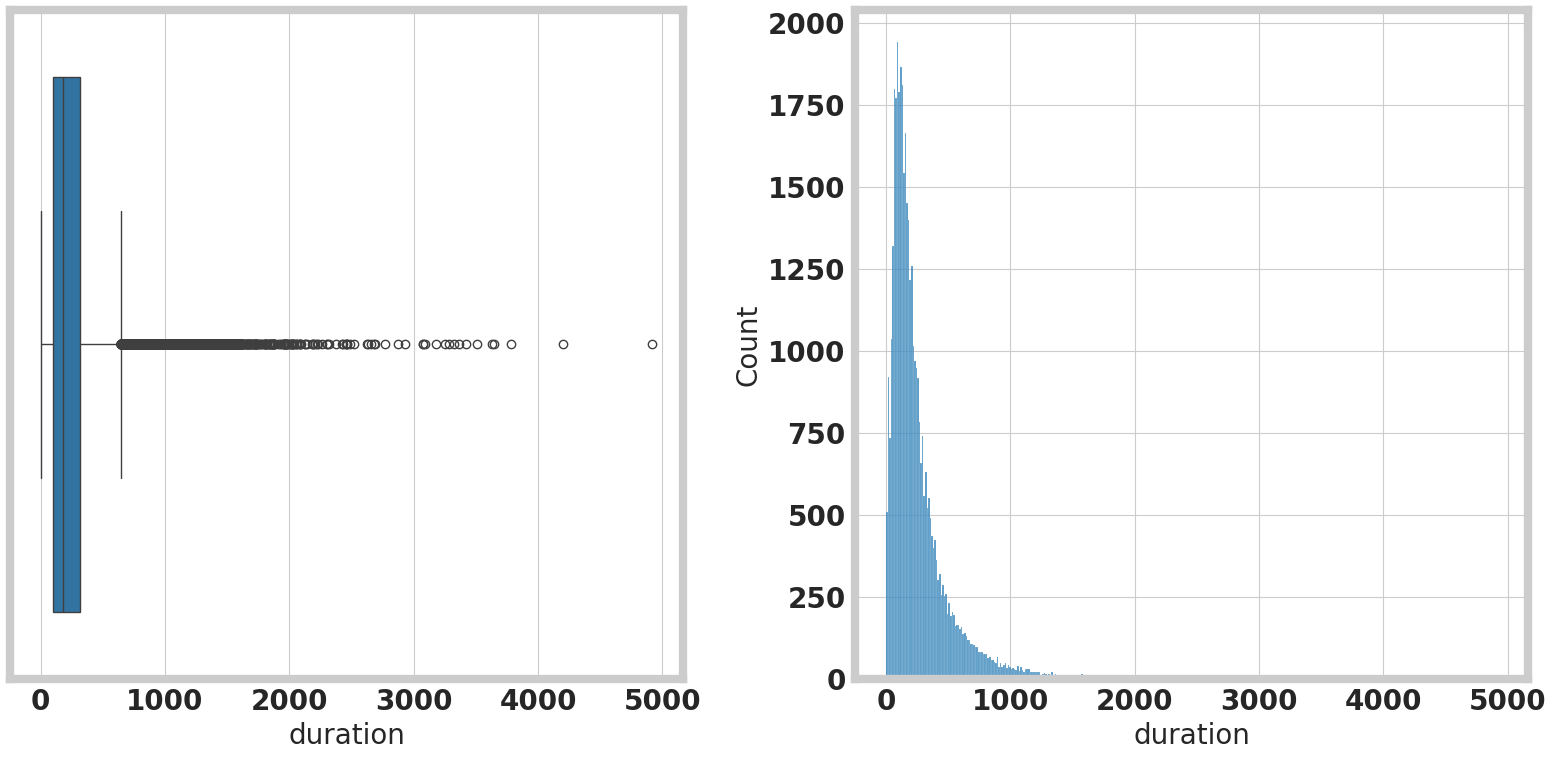

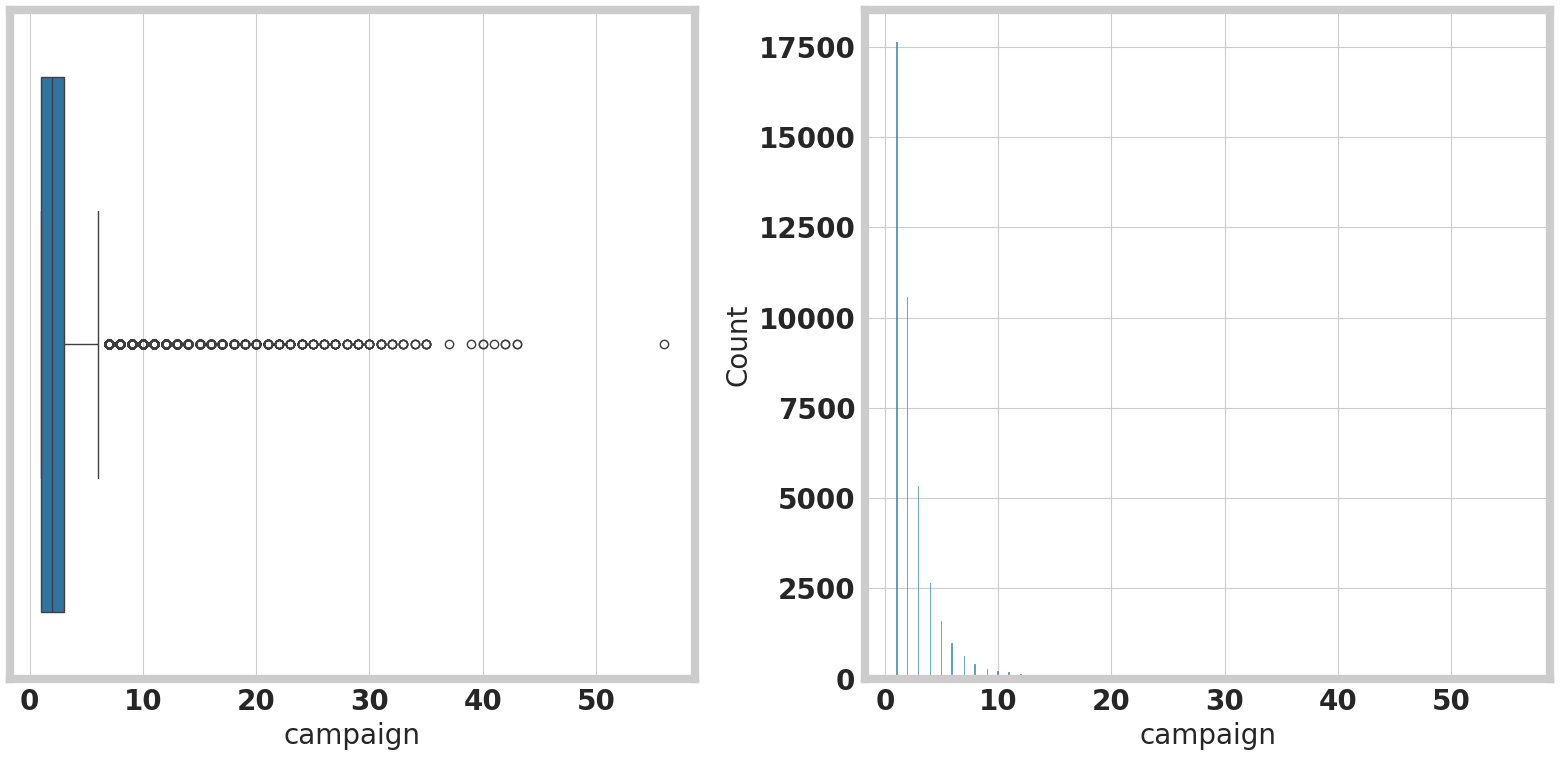

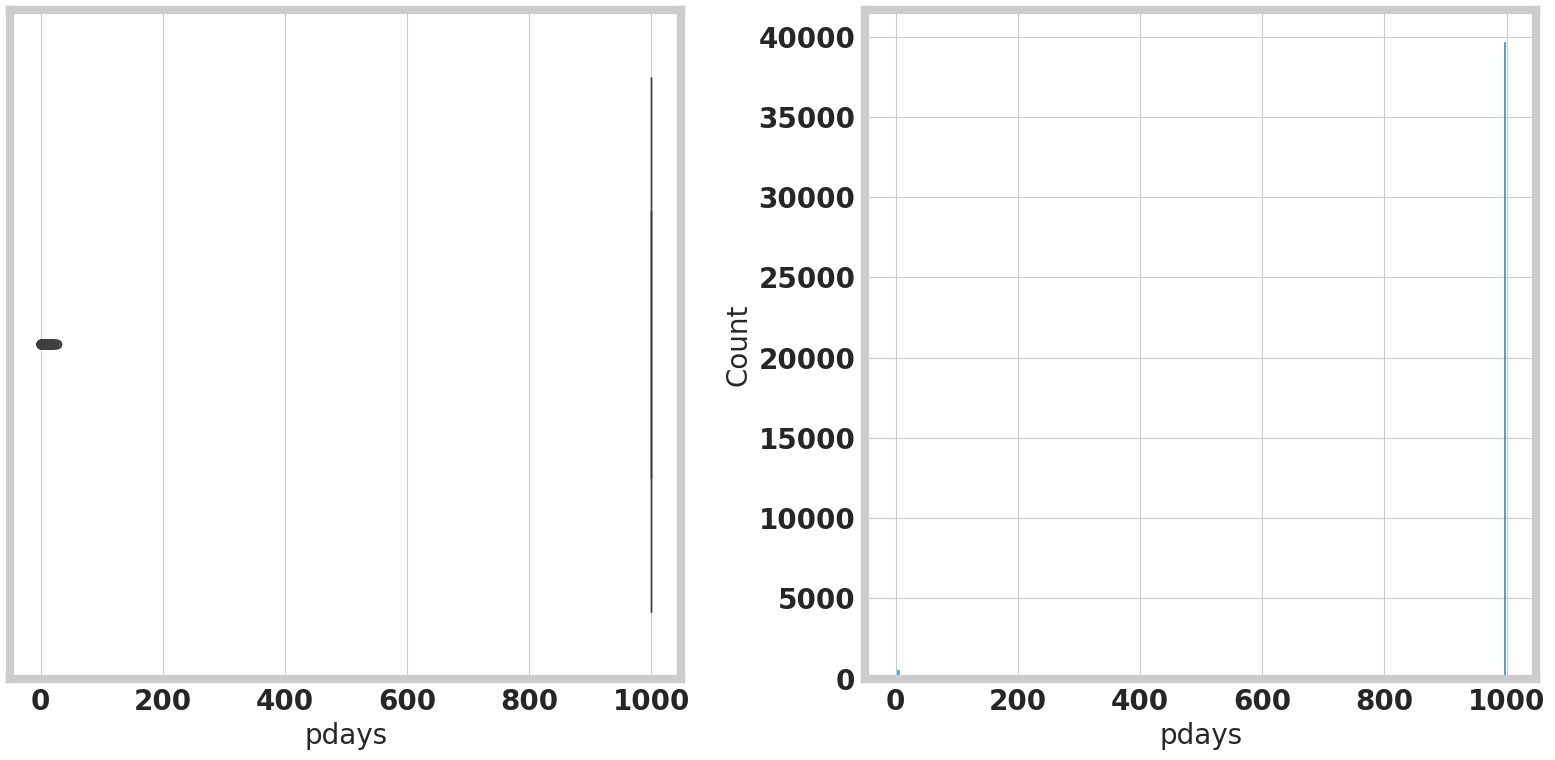

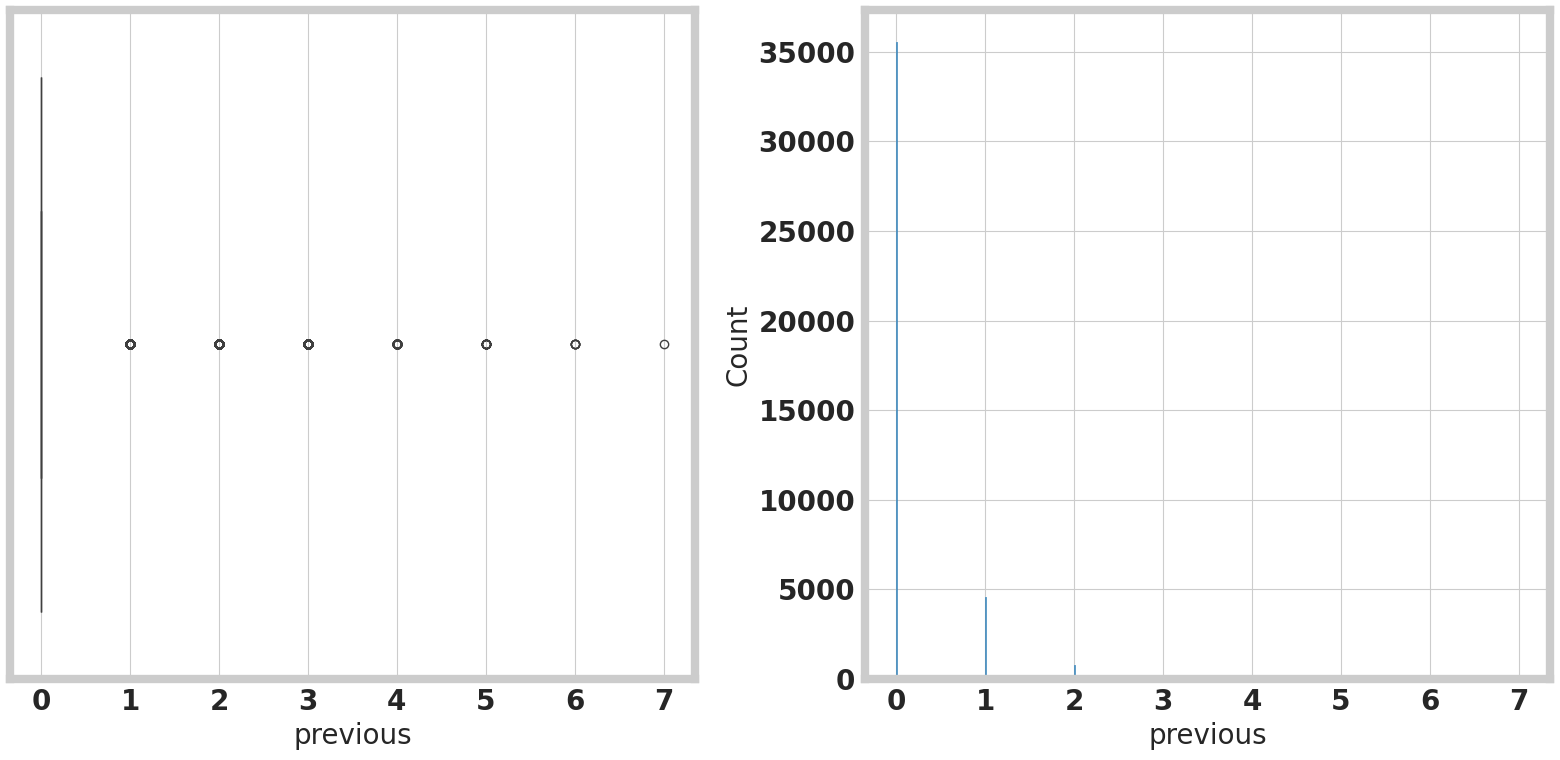

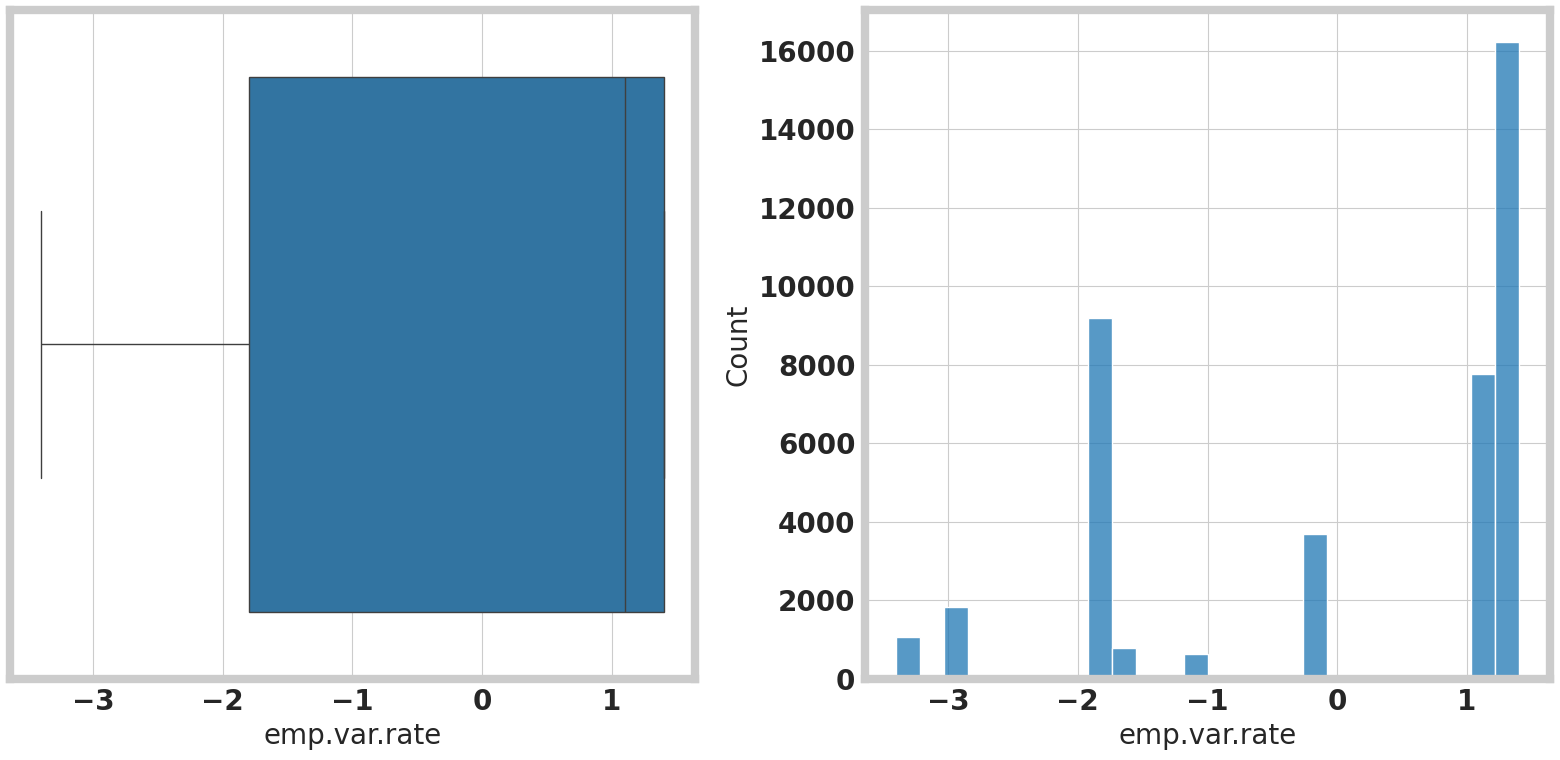

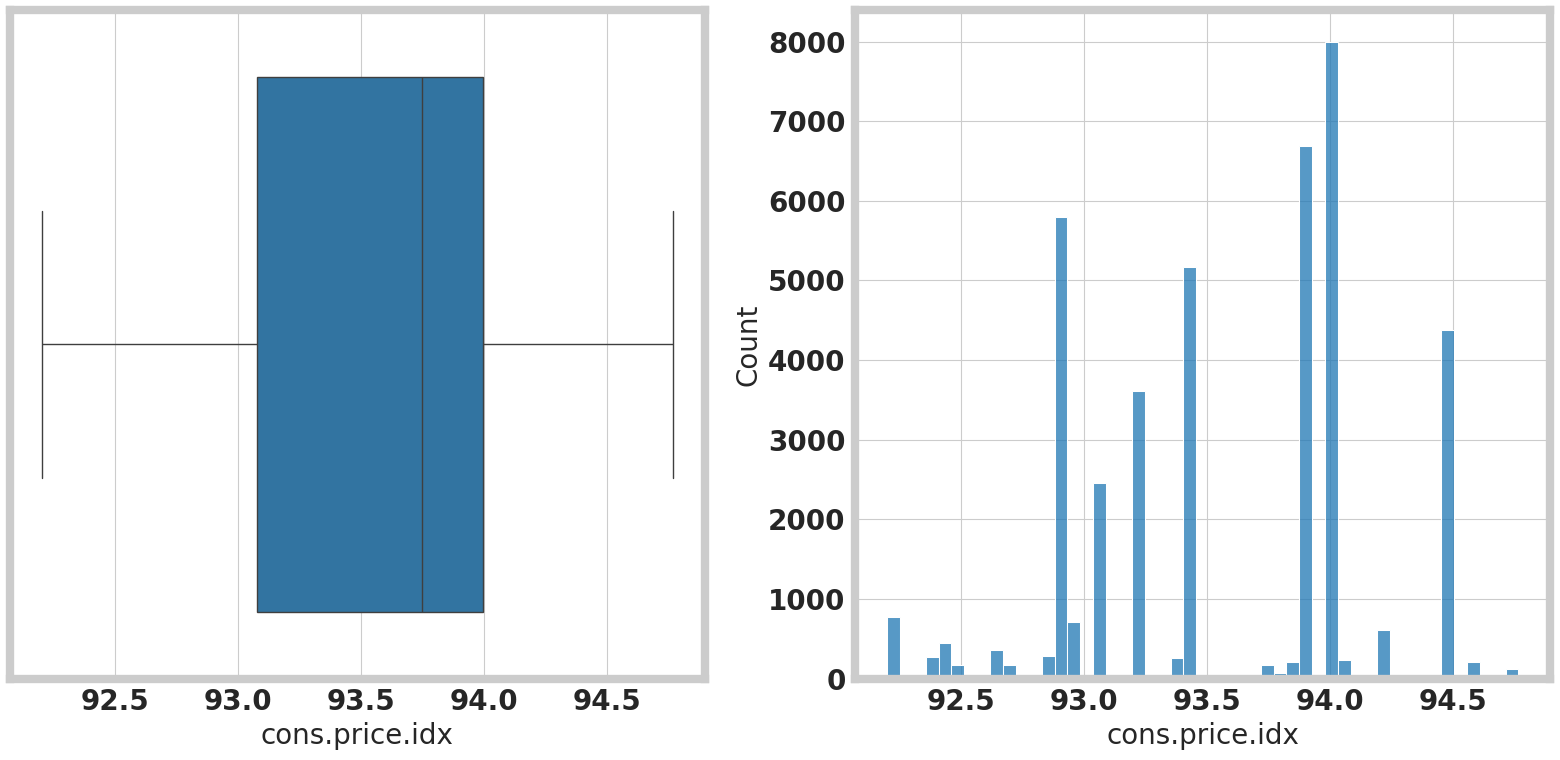

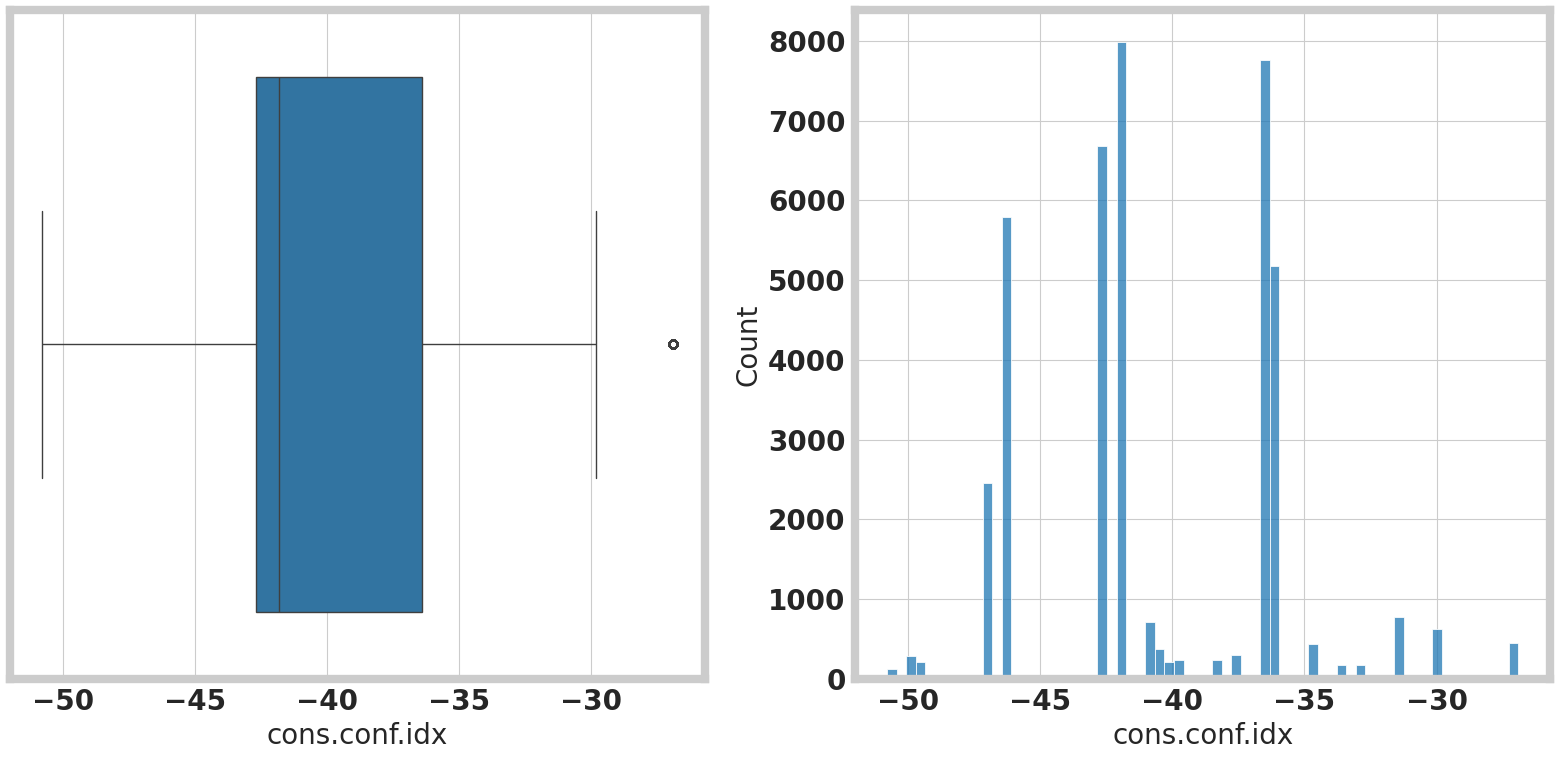

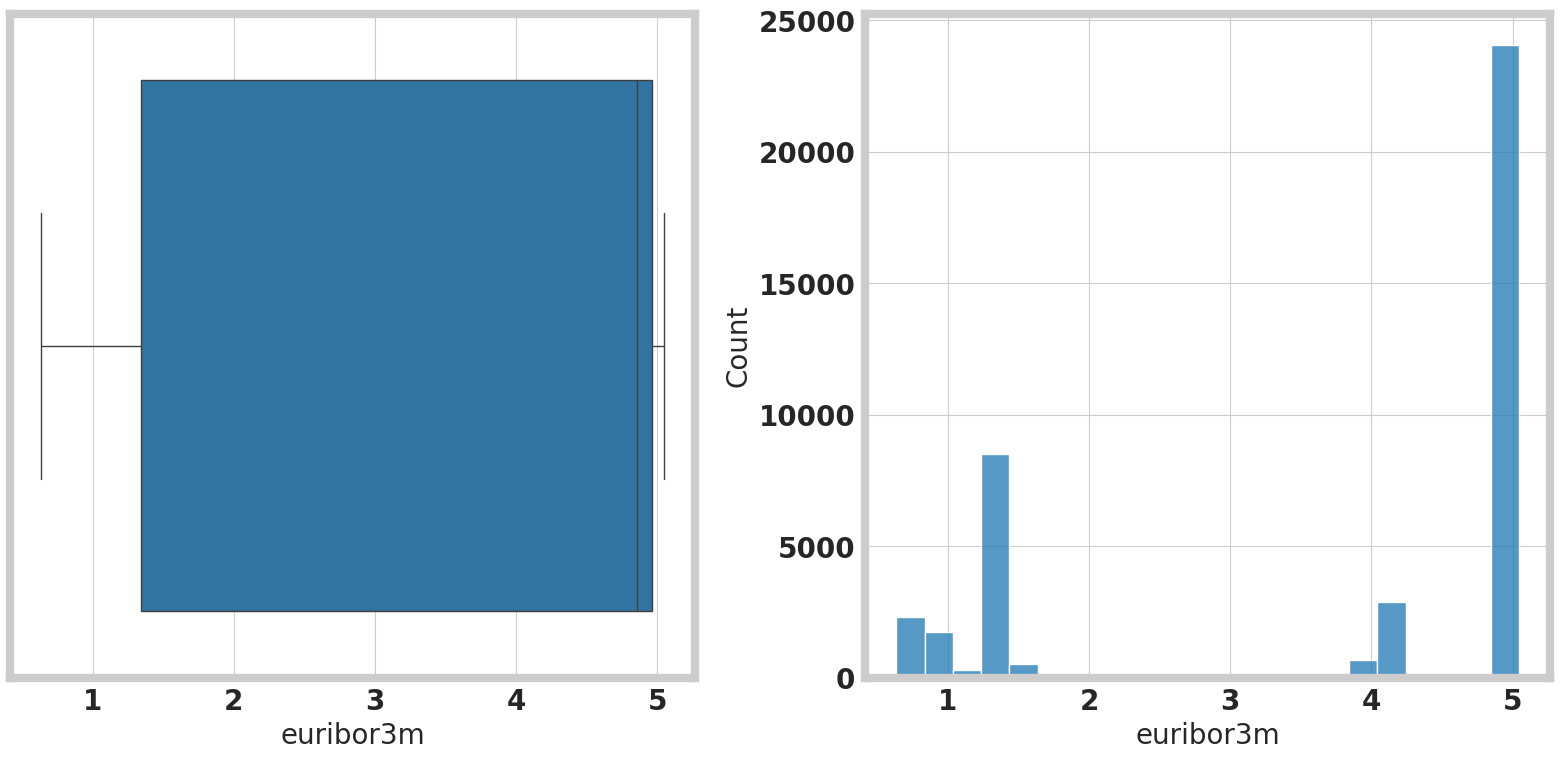

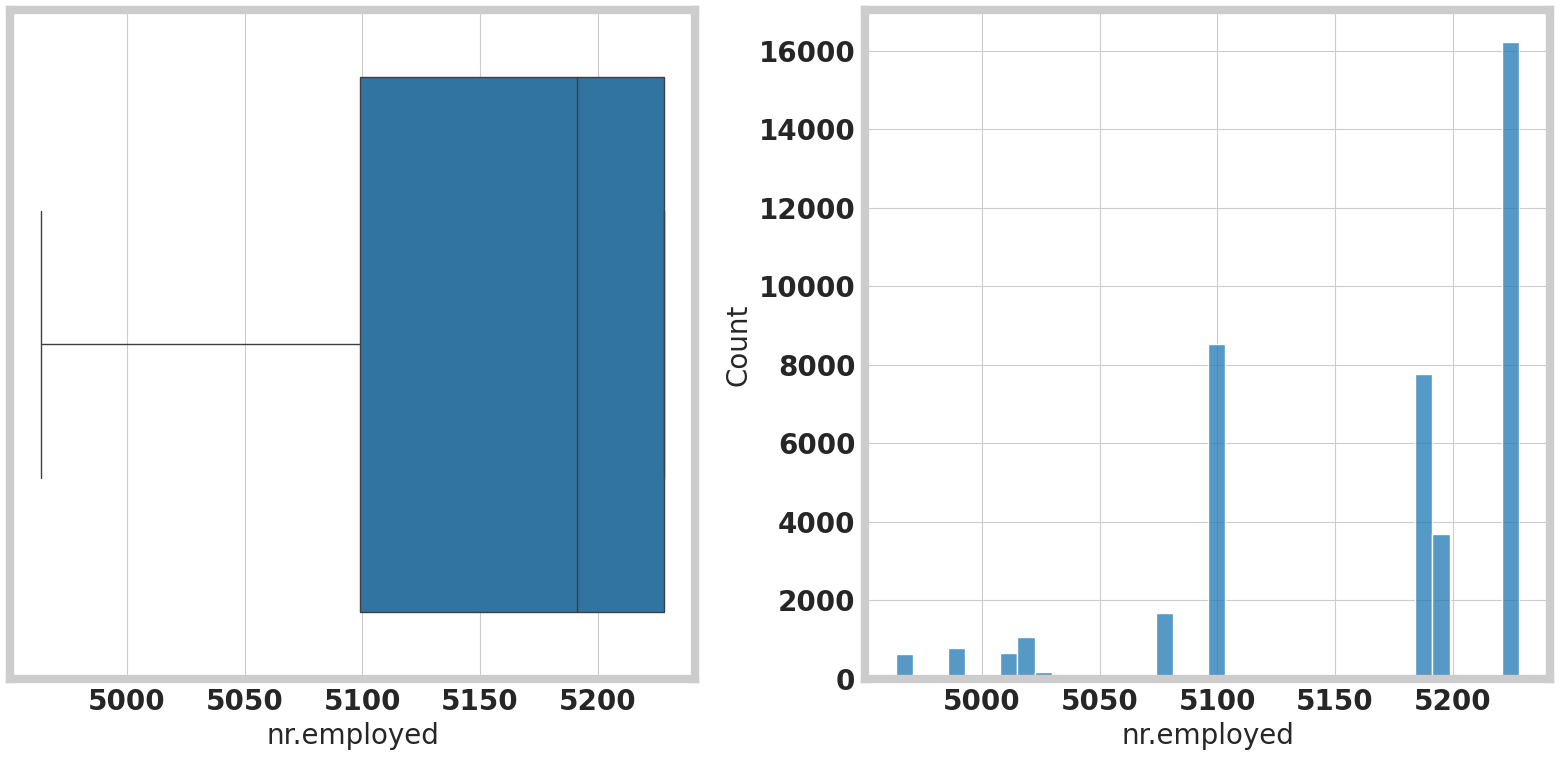

In [25]:
inspect_numerical_outliers(df)

In [26]:
def winsorize(df:pd.DataFrame, lower_percentile: float = 0.05, upper_percentile:float = 0.95,
 exclude_columns: List = None) -> pd.DataFrame:
    """
    Apply winsorization to numeric columns in a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame.
    lower_percentile (float): The lower percentile for capping.
    upper_percentile (float): The upper percentile for capping.
    exclude_columns (list): List of columns to exclude from winsorization.
    
    Returns:
    pd.DataFrame: The DataFrame with winsorized numeric columns.
    """
    df_winsorized = df.copy()
    numeric_columns = df_winsorized.select_dtypes(include='number').columns
    winsorize_columns = set(numeric_columns) - set(exclude_columns) if exclude_columns else numeric_columns
    
    for col in winsorize_columns:
        lower_value = df_winsorized[col].quantile(lower_percentile)
        upper_value = df_winsorized[col].quantile(upper_percentile)
        df_winsorized[col] = np.where(df_winsorized[col] < lower_value, lower_value, df_winsorized[col])
        df_winsorized[col] = np.where(df_winsorized[col] > upper_value, upper_value, df_winsorized[col])
    
    return df_winsorized


In [27]:
winsorized_df = winsorize(df, exclude_columns = ['pdays'])

In [28]:
from scipy.stats import mannwhitneyu

def plot_kde_before_after(df, winsorized_df, exclude_columns=None):
    """
    Plot KDE for all numeric columns before and after winsorization and print Wilcoxon rank-sum test results.
    
    Parameters:
    df (pd.DataFrame): The original DataFrame.
    winsorized_df (pd.DataFrame): The winsorized DataFrame.
    exclude_columns (list): List of columns to exclude from plotting.
    """
    numeric_columns = df.select_dtypes(include='number').columns
    plot_columns = set(numeric_columns) - set(exclude_columns) if exclude_columns else numeric_columns
    
    for column in plot_columns:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))

        # Stacked KDE plots
        sns.kdeplot(df[column], ax=ax, label='Original', fill=True, alpha=0.5)
        sns.kdeplot(winsorized_df[column], ax=ax, label='Winsorized', fill=True, alpha=0.5)
        ax.set_title(f'Stacked KDE Plot for {column}', fontweight = 'bold')
        ax.set_xlabel(f"{column.capitalize()}", fontweight = 'bold')
        ax.set_ylabel(f"Density", fontweight = 'bold')
        ax.legend(labelcolor = 'linecolor')

        plt.tight_layout()
        plt.show()

        # Wilcoxon rank-sum test
        u_stat, p_value = mannwhitneyu(df[column], winsorized_df[column])
        print(f"Wilcoxon rank-sum test for '{column}': U Statistic: {u_stat:.4f}, P-value: {p_value:.4f}")
        if p_value < 0.05:
            print(f"The distributions of '{column}' are significantly different (p < 0.05).")
        else:
            print(f"The distributions of '{column}' are not significantly different (p >= 0.05).")


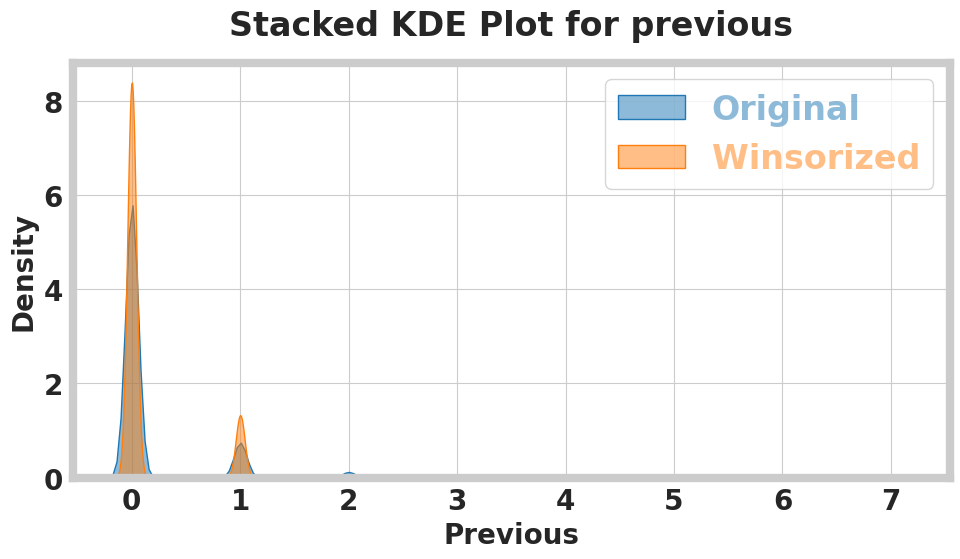

Wilcoxon rank-sum test for 'previous': U Statistic: 851218172.0000, P-value: 0.1408
The distributions of 'previous' are not significantly different (p >= 0.05).


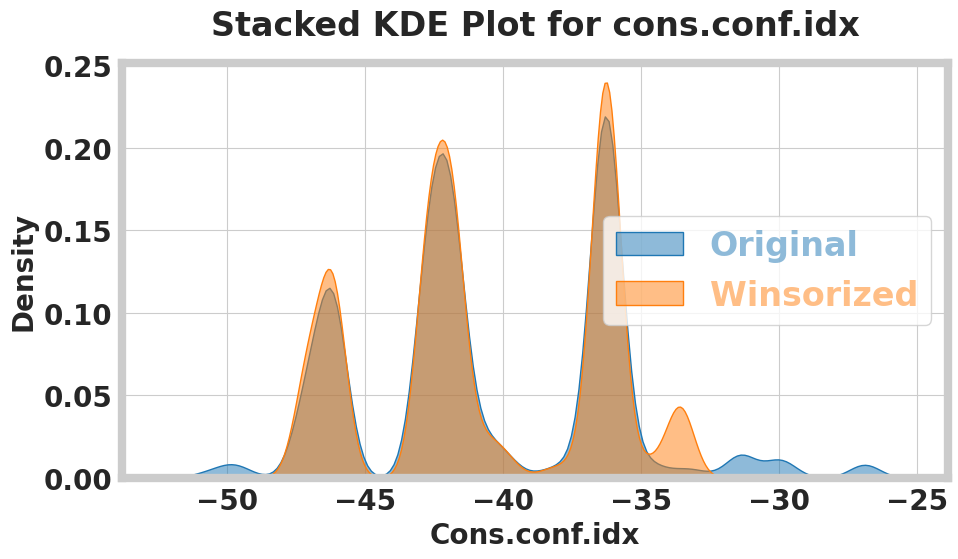

Wilcoxon rank-sum test for 'cons.conf.idx': U Statistic: 849487809.5000, P-value: 0.7090
The distributions of 'cons.conf.idx' are not significantly different (p >= 0.05).


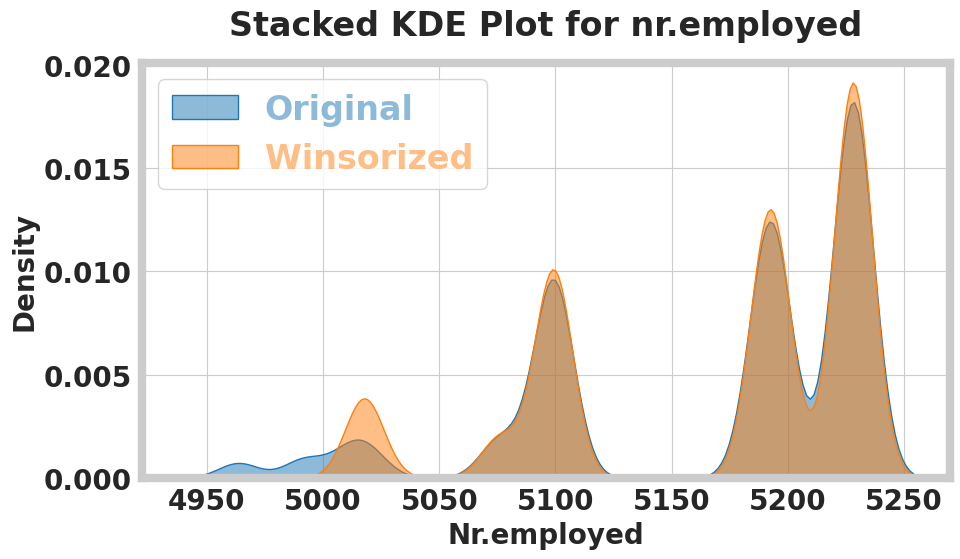

Wilcoxon rank-sum test for 'nr.employed': U Statistic: 845005931.0000, P-value: 0.3259
The distributions of 'nr.employed' are not significantly different (p >= 0.05).


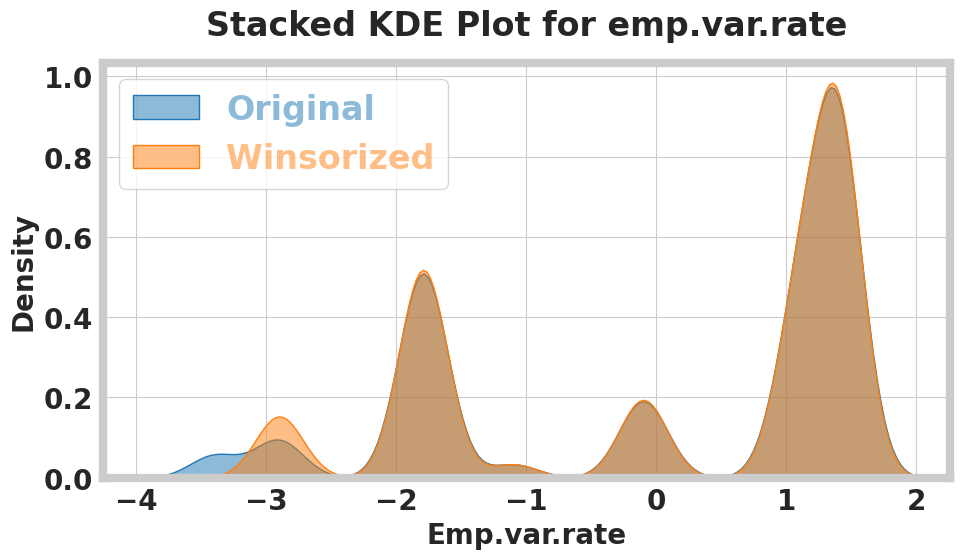

Wilcoxon rank-sum test for 'emp.var.rate': U Statistic: 846419593.0000, P-value: 0.5811
The distributions of 'emp.var.rate' are not significantly different (p >= 0.05).


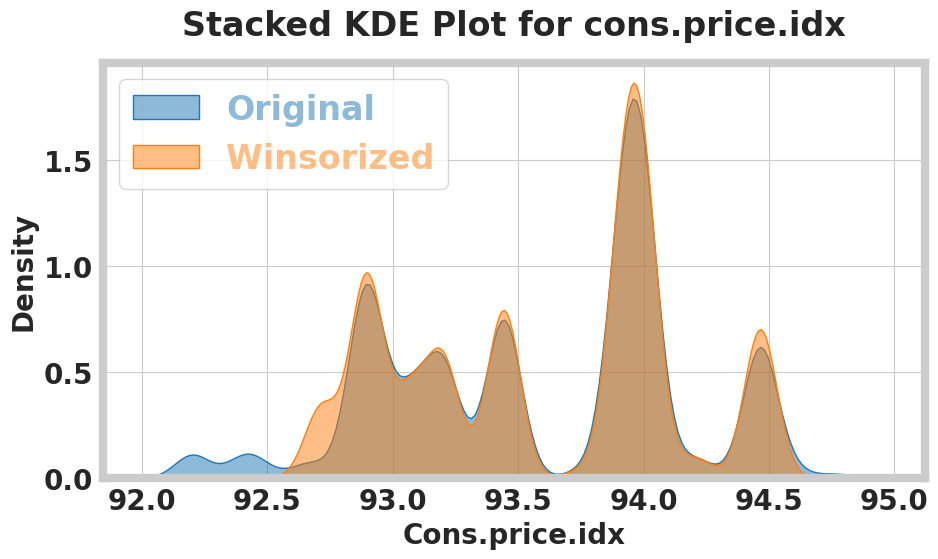

Wilcoxon rank-sum test for 'cons.price.idx': U Statistic: 846795053.5000, P-value: 0.6723
The distributions of 'cons.price.idx' are not significantly different (p >= 0.05).


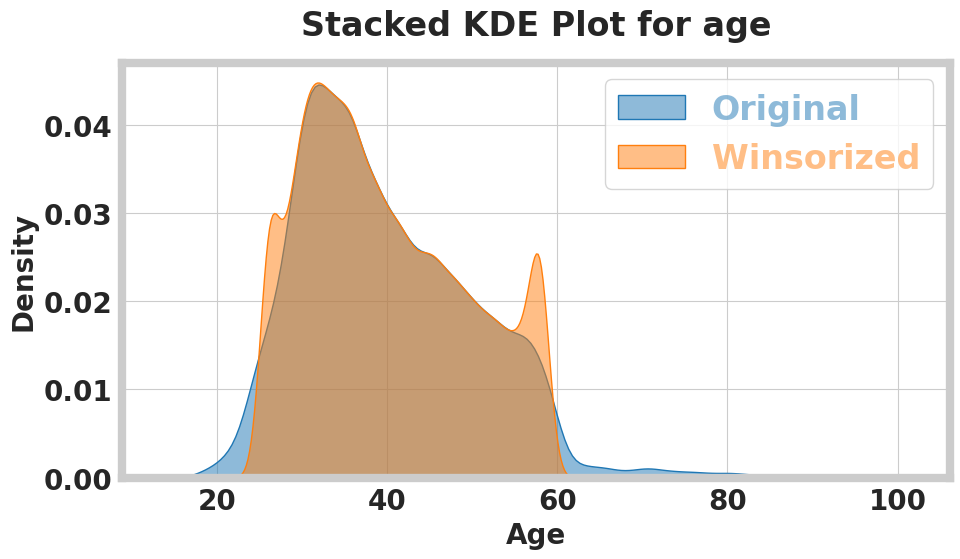

Wilcoxon rank-sum test for 'age': U Statistic: 848104556.0000, P-value: 0.9717
The distributions of 'age' are not significantly different (p >= 0.05).


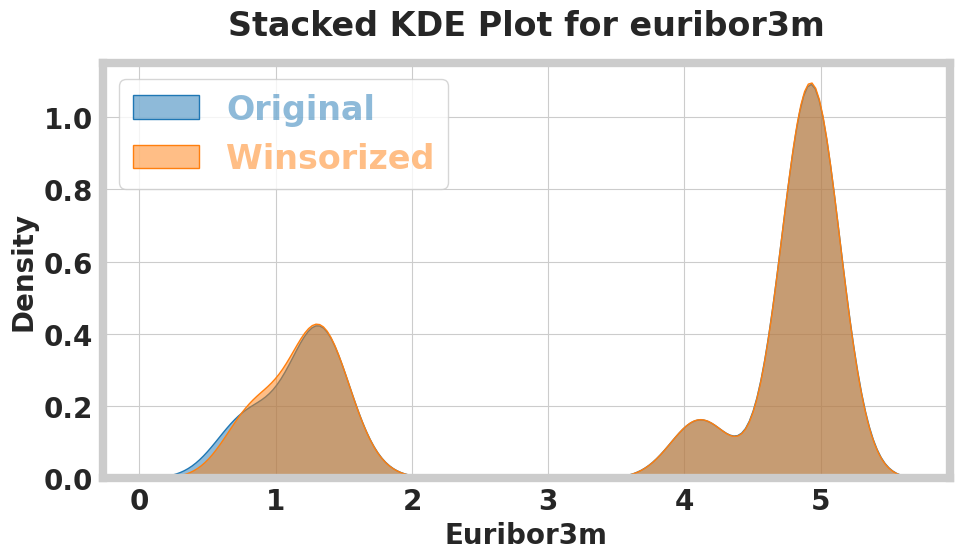

Wilcoxon rank-sum test for 'euribor3m': U Statistic: 848320292.0000, P-value: 0.9779
The distributions of 'euribor3m' are not significantly different (p >= 0.05).


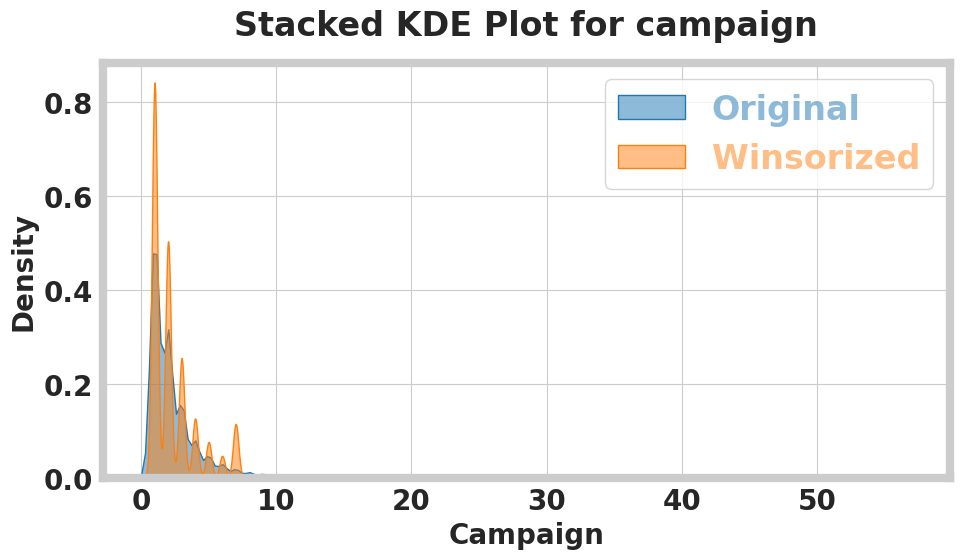

Wilcoxon rank-sum test for 'campaign': U Statistic: 850363403.0000, P-value: 0.5095
The distributions of 'campaign' are not significantly different (p >= 0.05).


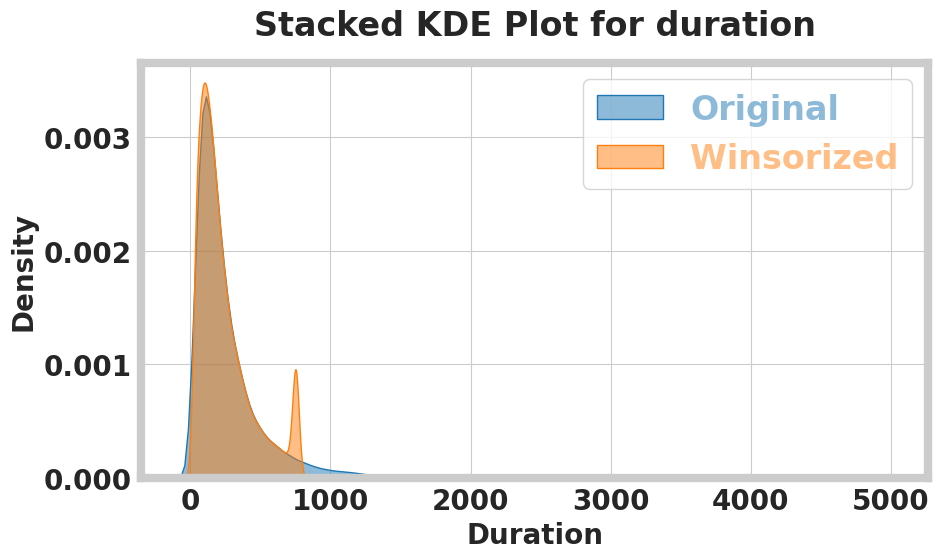

Wilcoxon rank-sum test for 'duration': U Statistic: 848245012.0000, P-value: 0.9955
The distributions of 'duration' are not significantly different (p >= 0.05).


In [29]:
plot_kde_before_after(df, winsorized_df, exclude_columns = ['pdays'])

In [30]:
df.select_dtypes(include = 'object').columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'Subscription'],
      dtype='str')

### Feature Importance and Correlation

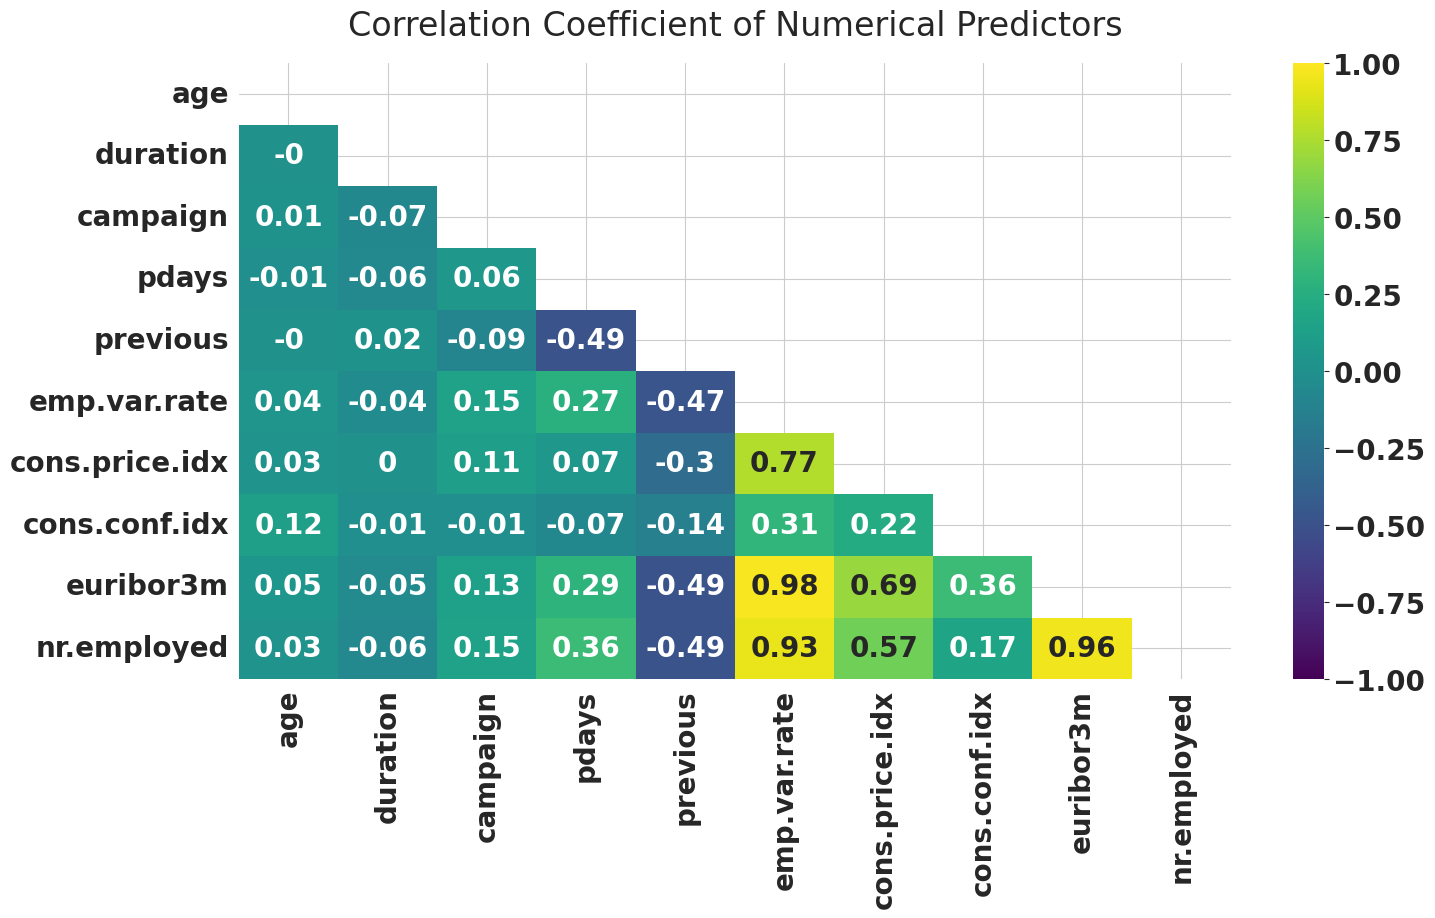

In [31]:
# Calculate the correlation matrix and round to two decimal places
corr_matrix = winsorized_df.select_dtypes(include='number').corr().round(2)

# Generate a mask to only show the bottom triangle
mask = np.triu(np.ones_like(corr_matrix, dtype = bool))

# Generate the heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(corr_matrix, annot = True, mask =mask, vmin = -1, vmax = 1, cmap = 'viridis')
plt.title('Correlation Coefficient of Numerical Predictors')
plt.show()

#### How do we remove above highly correlated features?
Eliminating features wantonly runs the risk of removing too much important information, which is detrimental to your efforts for building a reliable model. Let use VIF for above numeric columns.

In [32]:
# load statmodels functions
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# compute the vif for all given features
def compute_vif(df):
    
    X = df.select_dtypes(include = 'number')
    # the calculation of variance inflation requires a constant
    X['intercept'] = 1
    
    # create dataframe to store vif values
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif = vif[vif['Variable']!='intercept']
    return vif

In [33]:
# Criterion: Remove variables with VIF >= 5.0
compute_vif(winsorized_df)

,Variable,VIF
0,age,1.014475
1,duration,1.013641
2,campaign,1.040828
3,pdays,1.453029
4,previous,1.597728
5,emp.var.rate,34.876415
6,cons.price.idx,4.980108
7,cons.conf.idx,2.889873
8,euribor3m,68.189999
9,nr.employed,40.108289


In [34]:
# Drop multicollinear features
winsorized_df.drop(columns = ['emp.var.rate', 'cons.price.idx', 'euribor3m', 'nr.employed'], inplace = True)

In [35]:
"""Positive value means the distribution is skewed to the right.
Negative value means the distribution is skewed to the left.
0 means perfect normal distribution. The bell shaped curve.
"""
winsorized_df.select_dtypes(include = 'number').skew().sort_values(ascending=False)

previous         2.116792
campaign         1.452851
duration         1.300622
age              0.414268
cons.conf.idx    0.007875
pdays           -4.922190
dtype: float64

In [36]:
# Encode categorical features
winsorized_df.select_dtypes(include = 'object').head()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,Subscription
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,no
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,no
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,no
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,no
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,no


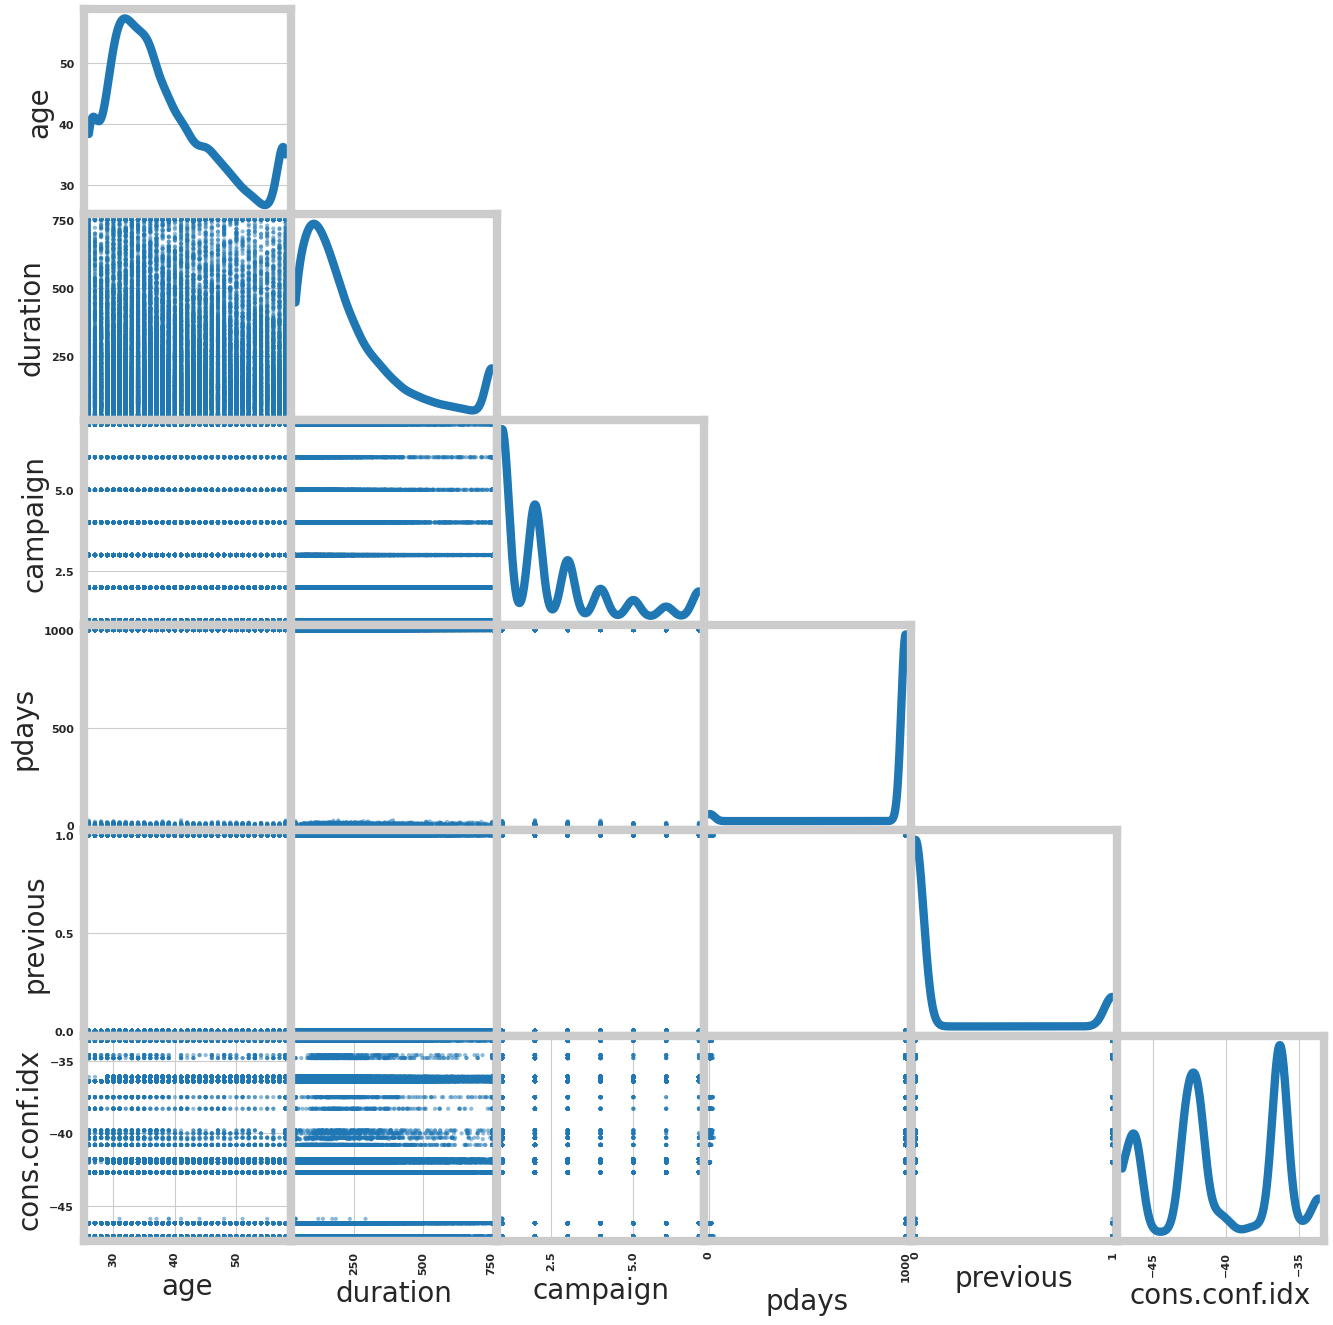

In [37]:
# Create scatter matrix plot
scatter_matrix = pd.plotting.scatter_matrix(winsorized_df, alpha=0.5, figsize=(16, 16), diagonal='kde')

# Hide the upper triangle
for i, j in zip(*np.triu_indices_from(scatter_matrix, 1)):
    scatter_matrix[i, j].set_visible(False)

plt.show()

In [38]:
winsorized_df['Subscription'] = winsorized_df['Subscription'].map({'yes': 1, 'no': 0})

In [39]:
winsorized_df['Subscription'].value_counts(normalize = True)

Subscription
0    0.887346
1    0.112654
Name: proportion, dtype: float64

#### Categorical Feature Modification
If more than three categories and some are sparse, mold sparses into 'other' categories. If three categories and one is sparse, imput with max frequency.

In [40]:
def replace_small_categories_with_mode(df, column, threshold = None):
    # Lets make a df copy
    df_copy = df.copy()

    # Calculate the proportions of each category
    category_proportions = df_copy[column].value_counts(normalize = True)
    
    if threshold is None:
        # Identify the category with the smallest proportion
        smallest_category = category_proportions.idxmin()
        small_categories = [smallest_category]
    else:
        # Identify small categories based on the given threshold
        small_categories = category_proportions[category_proportions <= threshold].index
    
    # Find the most frequent category
    most_frequent_category = category_proportions.idxmax()
    
    # Replace small categories with the most frequent category if number of 
    # categories in geater than 2
    if len(category_proportions) > 2:
        df_copy[column] = df_copy[column].map(lambda x: most_frequent_category if 
        x in small_categories else x)
    
    return df_copy

In [41]:
# mutate for categorical column where it has three categories and one is rare (< 1% or so)
mutate_with_mode = ['housing', 'default', 'loan', 'marital']

for col in mutate_with_mode:
    winsorized_df = replace_small_categories_with_mode(winsorized_df, column = col)

Wherever we have less than x% for each feature, categorize that into 'others'.

In [42]:
def merge_small_categories(df, column, threshold = 0.05, min_categories = 4, categories_under_threshold = 2):
    """
    Replace categories in a given column with 'Others' if they account for less than the specified 
    threshold and if the total number of unique categories is greater than the specified number and 
    at least two categories have a normalized value less than the threshold.
    
    Parameters:
    df (pd.DataFrame): The DataFrame containing the column.
    column (str): The name of the column to process.
    threshold (float): The threshold for the minimum proportion of each category (default is 0.05).
    min_categories (int): The minimum number of unique categories required to consider replacing 
    small categories (default is 4).
    categories_under_threshold (int): The minimum number of categories that must have a normalized value 
    less than the threshold to trigger the replacement (default is 2).
    
    Returns:
    pd.DataFrame: The DataFrame with small categories replaced by 'Others'.
    """
    # Lets create a copy
    df_copy = df.copy(deep = True)

    # Calculate the proportion of each category
    category_proportions = df_copy[column].value_counts(normalize = True)
    
    # Identify small categories
    small_categories = category_proportions[category_proportions < threshold].index
    
    # Check if the total number of unique categories is greater than the specified number
    if len(category_proportions) >= min_categories:
        # Check if at least the specified number of categories have a normalized value less than the threshold
        if (category_proportions < threshold).sum() >= categories_under_threshold:
            # Replace small categories with 'Others' using map and mask
            df_copy[column] = df_copy[column].map(lambda x: 'Others' if x in small_categories else x)
    
    return df_copy

In [43]:
merge_threshold = {
    'job': 0.03,
    'education': 0.05
}

for col, threshold in merge_threshold.items():
    winsorized_df = merge_small_categories(winsorized_df, col, threshold = threshold)

In [44]:
# Mapping dictionary (use Q2, Q3 and write Q1, Q4 as 'Others')
month_to_quarter = {
    'jan': 'Others', 'feb': 'Others', 'mar': 'Others',
    'apr': 'Q2', 'may': 'Q2', 'jun': 'Q2',
    'jul': 'Q3', 'aug': 'Q3', 'sep': 'Q3',
    'oct': 'Others', 'nov': 'Others', 'dec': 'Others'
}

# Lets create a new column called quarters from months
winsorized_df['quarter'] = winsorized_df['month'].map(month_to_quarter)

#### Categorical Features Independence

In [45]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calculate Cramér's V for two categorical variables."""
    confusion_matrix = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    minDim = min(confusion_matrix.shape) - 1
    V = np.sqrt((chi2 / n) / minDim)
    return V, p

def filter_weak_associations(df, target):
    """
    Calculate Cramér's V for each categorical feature with the target and return a DataFrame 
    with the column names, Cramér's V values, and p-values.
    
    Parameters:
    df (pd.DataFrame): The DataFrame containing the features and target.
    target (str): The name of the target column.
    
    Returns:
    pd.DataFrame: A DataFrame with the column names, Cramér's V values, and p-values.
    """
    categorical_columns = df.select_dtypes(include=['object']).columns
    results = []

    for col in categorical_columns:
        if col != target:
            V, p = cramers_v(df[col], df[target])
            results.append({'Column': col, 'Cramér\'s V': V, 'p-value': p})
    
    results_df = pd.DataFrame(results)
    return results_df

results_df = filter_weak_associations(winsorized_df, 'Subscription')
print(results_df)


         Column  Cramér's V        p-value
0           job    0.131119  1.281344e-147
1       marital    0.054153   5.915954e-27
2     education    0.068283   9.356020e-39
3       default    0.099199   3.851278e-90
4       housing    0.011008   2.547931e-02
5          loan    0.004359   3.763354e-01
6       contact    0.144693  1.525986e-189
7         month    0.274395   0.000000e+00
8   day_of_week    0.025195   2.958482e-05
9      poutcome    0.320488   0.000000e+00
10      quarter    0.110062  4.547395e-109


In [46]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calculate Cramér's V statistic for categorical-categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2, p, dof, _ = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    cramers_v_value = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
    return cramers_v_value, chi2, p, dof

def cat_feature_associations(df, target=None):
    """
    Calculate Cramér's V for each combination of categorical features and include chi-squared test results.
    
    Parameters:
    df (pd.DataFrame): The DataFrame containing the features and target.
    target (str, optional): The name of the target column. If provided, calculate associations with the target.
    
    Returns:
    pd.DataFrame: A DataFrame with the column names, Cramér's V values, chi-squared statistic, p-values, and degrees of freedom.
    """
    categorical_columns = df.select_dtypes(include=['object']).columns
    results = []

    if target:
        for col in categorical_columns:
            if col != target:
                V, chi2, p, dof = cramers_v(df[col], df[target])
                results.append({'Column1': col, 'Column2': target, 'Cramér\'s V': V, 
                 'p-value': p, 'Degrees of Freedom': dof})
    else:
        for i, col1 in enumerate(categorical_columns):
            for col2 in categorical_columns[i+1:]:
                V, chi2, p, dof = cramers_v(df[col1], df[col2])
                results.append({'Column1': col1, 'Column2': col2, 
                'Cramér\'s V': V, 'p-value': p, 'Degrees of Freedom': dof})
    
    results_df = pd.DataFrame(results)

    return results_df

# Example usage
results_df = cat_feature_associations(winsorized_df)
print(results_df)

        Column1      Column2  Cramér's V        p-value  Degrees of Freedom
0           job      marital    0.162199   0.000000e+00                  16
1           job    education    0.375663   0.000000e+00                  48
2           job      default    0.203359   0.000000e+00                   8
3           job      housing    0.014018   4.105902e-02                   8
4           job         loan    0.017429   8.564484e-03                   8
5           job      contact    0.118831  4.045355e-122                   8
6           job        month    0.111202   0.000000e+00                  72
7           job  day_of_week    0.014481   3.224570e-04                  32
8           job     poutcome    0.082730  4.439087e-113                  16
9           job      quarter    0.149165   0.000000e+00                  16
10      marital    education    0.141662   0.000000e+00                  12
11      marital      default    0.134551  4.479010e-163                   2
12      mari

In [47]:
cat_feature_associations(winsorized_df, target = 'Subscription')

,Column1,Column2,Cramér's V,p-value,Degrees of Freedom
0,job,Subscription,0.130378,1.281344e-147,8
1,marital,Subscription,0.053703,5.915954e-27,2
2,education,Subscription,0.067209,9.356020e-39,6
3,default,Subscription,0.099078,3.851278e-90,1
4,housing,Subscription,0.009844,2.547931e-02,1
5,loan,Subscription,0.000000,3.763354e-01,1
6,contact,Subscription,0.144611,1.525986e-189,1
7,month,Subscription,0.274000,0.000000e+00,9
8,day_of_week,Subscription,0.023188,2.958482e-05,4
9,poutcome,Subscription,0.320416,0.000000e+00,2


In [48]:
# Since day_of_week has no association with target and we have 
# quarter for month lets drop these two columns
winsorized_df.drop(columns = ['month', 'day_of_week'], inplace = True)

### Model Training, Testing, Validation and Evaluation

In [49]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve,\
roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay, accuracy_score, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
import statsmodels.api as sm
from collections import defaultdict
import time

In [50]:
def one_hot_encode(df):
    """
    Perform one-hot encoding on all categorical features in the DataFrame 
    using sklearn's OneHotEncoder.
    
    Parameters:
    df (pd.DataFrame): The DataFrame containing the features.
    
    Returns:
    pd.DataFrame: The DataFrame with one-hot encoded columns.
    """
    # Select categorical columns
    categorical_columns = df.select_dtypes(include=['object']).columns
    
    # Initialize OneHotEncoder with drop='first' to drop the first category
    encoder = OneHotEncoder(drop='first', sparse_output=False)
    
    # Fit and transform the categorical columns
    one_hot_encoded = encoder.fit_transform(df[categorical_columns])
    
    # Create a DataFrame with the one-hot encoded columns
    one_hot_df = pd.DataFrame(one_hot_encoded, columns = encoder.get_feature_names_out(categorical_columns))
    
    # Concatenate the one-hot encoded DataFrame with the original DataFrame
    df_encoded = pd.concat([df.drop(categorical_columns, axis = 1), one_hot_df], axis = 1)
    
    return df_encoded

encoded_df = one_hot_encode(winsorized_df)


In [51]:
# Create features and target from winsorized_df
X = encoded_df.drop(columns = 'Subscription')
y = encoded_df['Subscription']

# Assuming y is your target series and X is your feature DataFrame
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, stratify = y, random_state = 42)
print("Train set size:", len(y_train))
print("Test set size:", len(y_test))

Train set size: 27595
Test set size: 13593


In [52]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Add a constant to the model (intercept)
X_train_scaled_const = sm.add_constant(X_train_scaled)

# Fit the logistic regression model
logit_model = sm.Logit(y_train, X_train_scaled_const).fit()

# Extract p-values
p_values = logit_model.pvalues

# Identify significant coefficients (e.g., p-value < 0.05)
significant_coeffs = p_values[p_values < 0.05]

print("Significant coefficients:")
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.228563
         Iterations 8
Significant coefficients:
                           Logit Regression Results                           
Dep. Variable:           Subscription   No. Observations:                27595
Model:                          Logit   Df Residuals:                    27565
Method:                           MLE   Df Model:                           29
Date:                Sat, 02 May 2026   Pseudo R-squ.:                  0.3508
Time:                        15:53:55   Log-Likelihood:                -6307.2
converged:                       True   LL-Null:                       -9714.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0110      0.035    -87.063      0.000      -3.079      -2.943
x1 

In [53]:
import io # Step 1: Add this import

# Extract the summary table as a DataFrame
summary = logit_model.summary()
summary_as_html = summary.tables[1].as_html()

# Step 2: Wrap the HTML string in io.StringIO()
summary_df = pd.read_html(io.StringIO(summary_as_html), header=0, index_col=0)[0]

# Replace the index with your column names
summary_df.index = ['const'] + list(X_train.columns)

summary_desired = summary_df.iloc[:, [0, 3]]
print(summary_desired)

                                 coef  P>|z|
const                         -3.0110  0.000
age                           -0.0176  0.544
duration                       1.2298  0.000
campaign                      -0.1161  0.000
pdays                         -0.3354  0.000
previous                       0.0416  1.000
cons.conf.idx                  0.2935  0.000
job_admin.                    -0.1551  0.000
job_blue-collar               -0.2821  0.000
job_entrepreneur              -0.1281  0.000
job_management                -0.1280  0.000
job_retired                    0.1244  0.000
job_self-employed             -0.1203  0.000
job_services                  -0.1961  0.000
job_technician                -0.1847  0.000
marital_married                0.0080  0.835
marital_single                 0.1307  0.001
education_basic.4y            -0.1122  0.005
education_basic.6y            -0.0734  0.040
education_basic.9y            -0.1984  0.000
education_high.school         -0.1736  0.001
education_

In [54]:
drop_columns = summary_desired[summary_desired.iloc[:, 1] > 0.05]
print(drop_columns)

                               coef  P>|z|
age                         -0.0176  0.544
previous                     0.0416  1.000
marital_married              0.0080  0.835
education_university.degree -0.1027  0.054
housing_yes                 -0.0175  0.458
loan_yes                    -0.0165  0.485
poutcome_nonexistent        -0.0416  1.000


In [55]:
import pickle
def save_model_results(fitted_model: str, file_name: str) -> None:
    filename = file_name + '.pkl'
    outfile = open(filename, 'wb')
    pickle.dump(fitted_model, outfile)
    outfile.close()

The coefficients for age, previous, marital_married, housing_yes, loan_yes, and poutcome_nonexistent are not significant as their p-values are greater than 0.05.

In [56]:
# dropping based on logistic model and earlier EDA
X_train_new = X_train.drop(columns = ['poutcome_nonexistent', 'previous', 'poutcome_nonexistent', 'loan_yes', 'housing_yes'])
X_test_new = X_test.drop(columns = ['poutcome_nonexistent', 'previous', 'poutcome_nonexistent', 'loan_yes', 'housing_yes'])

logit = Pipeline([('scalar', StandardScaler()),
                  ('model', LogisticRegression(class_weight= 'balanced', solver = 'liblinear'))
])

logit.fit(X_train_new, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scalar', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [57]:
logit.score(X_train_new, y_train)

0.8385939481790179

In [58]:
logit.score(X_test_new, y_test)

0.8343264915765467

In [59]:
f1_score(y_test, logit.predict(X_test_new))

0.5224766751484309

In [60]:
# Extract the logistic regression model from the pipeline
logistic_model = logit.named_steps['model']

# Get the coefficients and exponentiate them to get the odds ratios
coefficients = np.exp(logistic_model.coef_[0])

# Create a Pandas Series with the column names
coeff_series = pd.Series(coefficients, index = X_train_new.columns).sort_values(ascending = False)

print(coeff_series)

duration                         4.080769
cons.conf.idx                    1.301207
marital_single                   1.200260
job_retired                      1.140393
poutcome_success                 1.116499
marital_married                  1.051201
age                              0.981569
education_university.degree      0.897248
education_basic.6y               0.892356
education_professional.course    0.880894
education_basic.4y               0.871136
job_self-employed                0.861478
campaign                         0.850921
job_entrepreneur                 0.847537
job_management                   0.836173
education_high.school            0.816032
quarter_Q2                       0.791160
job_admin.                       0.785060
job_technician                   0.772964
education_basic.9y               0.772821
job_services                     0.766186
job_blue-collar                  0.680728
default_unknown                  0.677913
pdays                            0

Text(0.5, 1.0, 'Feature Importance Using Logistic Regression')

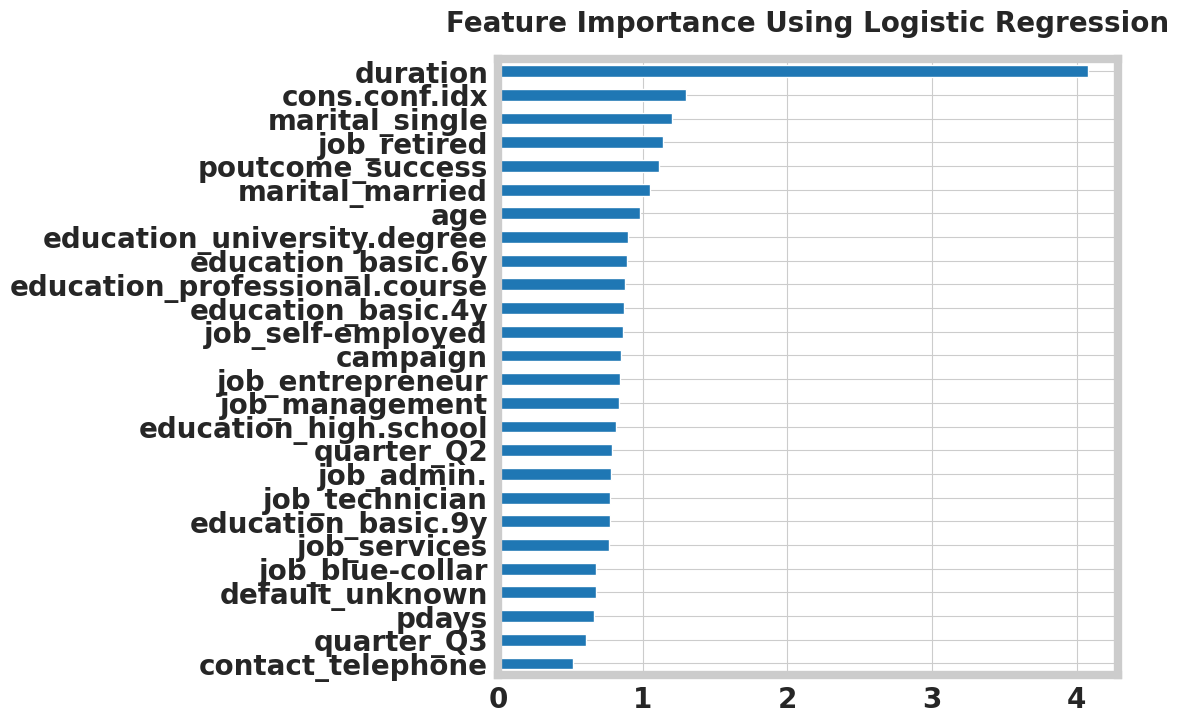

In [61]:
plt.figure(figsize = (8, 8))
coeff_series.sort_values().plot.barh()
plt.title("Feature Importance Using Logistic Regression", fontdict= {'fontweight':'bold', 'fontsize': 20})

#### LogisticRegression, RandomForestClassifier, SVMClassifier, KNeighborsClassifier, XGBoostClassifier

In [62]:
# Define the models with class_weight = 'balanced'
models = {
    'logistic': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter = 1000, class_weight='balanced'))
    ]),
    'randomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(class_weight='balanced', max_depth = 7))
    ]),
    'svm': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(probability = True, class_weight='balanced'))
    ]),
    'knn': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=5))
    ]),
    'xgboost': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', XGBClassifier(use_label_encoder = False, eval_metric = 'logloss', scale_pos_weight = 1))
    ])
}

# Initialize the scores dictionary using defaultdict
scores = defaultdict(list)

# Train and evaluate each model
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_new, y_train)
    end_time = time.time()
    y_train_pred = model.predict(X_train_new)
    y_test_pred = model.predict(X_test_new)
    y_test_proba = model.predict_proba(X_test_new)[:, 1]
    save_model_results(model, name)
    scores['model'].append(name)
    scores['train_time_sec'].append(end_time - start_time)
    scores['train_score'].append(model.score(X_train_new, y_train))
    scores['test_score'].append(model.score(X_test_new, y_test))
    scores['train_precision'].append(precision_score(y_train, y_train_pred))
    scores['test_precision'].append(precision_score(y_test, y_test_pred))
    scores['train_recall'].append(recall_score(y_train, y_train_pred))
    scores['test_recall'].append(recall_score(y_test, y_test_pred))
    scores['test_f1_score'].append(f1_score(y_test, y_test_pred))
    scores['test_roc_auc_score'].append(roc_auc_score(y_test, y_test_proba))

# Convert scores to DataFrame for better visualization
scores_df = pd.DataFrame(scores)
print(scores_df)

          model  train_time_sec  train_score  test_score  train_precision  \
0      logistic        0.876128     0.838485    0.834326         0.393892   
1  randomForest        1.777875     0.850843    0.844920         0.421634   
2           svm      126.143042     0.846458    0.833223         0.416814   
3           knn        0.045044     0.923682    0.898109         0.738242   
4       xgboost       19.509719     0.953579    0.909512         0.839777   

   test_precision  train_recall  test_recall  test_f1_score  \
0        0.386813      0.804760     0.804703       0.522477   
1        0.409419      0.871341     0.851731       0.553011   
2        0.390736      0.908974     0.859569       0.537253   
3        0.580931      0.499839     0.342260       0.430744   
4        0.618597      0.726600     0.512737       0.560714   

   test_roc_auc_score  
0            0.901675  
1            0.923333  
2            0.913579  
3            0.829886  
4            0.939535  


In [63]:
def load_model(file_name: str) -> Any:
    with open(file_name, 'rb') as infile:
        loaded_model = pickle.load(infile)
    return loaded_model

In [64]:
# Example how to load saved pkl file
load_model('logistic.pkl')

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may n

In [65]:
# Fine tuning xgboost model

# Define parameter grid
params_dict = {
    'min_child_weight': [1, 5, 10],
    'gamma': [0.5, 1, 1.5, 2, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'max_depth': [3, 4, 5]
}

# Set up Stratified K-Fold cross-validation
folds = 5
skf = StratifiedKFold(n_splits = folds, shuffle = True, random_state = 42)

# Initialize XGBoost classifier
xgb = XGBClassifier(use_label_encoder = False, eval_metric = 'logloss', scale_pos_weight = 1)

# Set up GridSearchCV
grid_search = GridSearchCV(estimator = xgb, param_grid = params_dict, scoring = 'roc_auc', cv = skf, verbose = 3, n_jobs = -1)

# Measure training time
start_time = time.time()
grid_search.fit(X_train_new, y_train)
end_time = time.time()
training_time = end_time - start_time

# Best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters: {best_params}")
print(f"Best ROC AUC score: {best_score}")
print(f"Training time: {training_time} seconds")

Fitting 5 folds for each of 405 candidates, totalling 2025 fits
[CV 1/5] END colsample_bytree=0.6, gamma=0.5, max_depth=3, min_child_weight=1, subsample=0.6;, score=0.939 total time=   0.4s
[CV 2/5] END colsample_bytree=0.6, gamma=0.5, max_depth=3, min_child_weight=1, subsample=0.6;, score=0.944 total time=   0.4s
[CV 3/5] END colsample_bytree=0.6, gamma=0.5, max_depth=3, min_child_weight=1, subsample=1.0;, score=0.943 total time=   0.3s
[CV 4/5] END colsample_bytree=0.6, gamma=0.5, max_depth=3, min_child_weight=1, subsample=1.0;, score=0.937 total time=   0.3s
[CV 5/5] END colsample_bytree=0.6, gamma=0.5, max_depth=3, min_child_weight=1, subsample=1.0;, score=0.941 total time=   0.3s
[CV 1/5] END colsample_bytree=0.6, gamma=0.5, max_depth=3, min_child_weight=5, subsample=0.6;, score=0.938 total time=   0.4s
[CV 4/5] END colsample_bytree=0.6, gamma=0.5, max_depth=3, min_child_weight=1, subsample=0.8;, score=0.938 total time=   0.4s
[CV 2/5] END colsample_bytree=0.6, gamma=0.5, max_dept

In [66]:
# Fit XGBoost model with best parameters
best_xgb = XGBClassifier(**best_params, use_label_encoder = False, eval_metric = 'logloss')
best_xgb.fit(X_train_new, y_train)

# Evaluate model
y_train_pred = best_xgb.predict(X_train_new)
y_test_pred = best_xgb.predict(X_test_new)
y_test_proba = best_xgb.predict_proba(X_test_new)[:, 1]

print("Training Metrics:")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Precision: {precision_score(y_train, y_train_pred)}")
print(f"Recall: {recall_score(y_train, y_train_pred)}")
print(f"F1 Score: {f1_score(y_train, y_train_pred)}")
print(f"ROC AUC: {roc_auc_score(y_train, best_xgb.predict_proba(X_train_new)[:, 1])}")

print("\nTesting Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred)}")
print(f"Precision: {precision_score(y_test, y_test_pred)}")
print(f"Recall: {recall_score(y_test, y_test_pred)}")
print(f"F1 Score: {f1_score(y_test, y_test_pred)}")
print(f"ROC AUC: {roc_auc_score(y_test, y_test_proba)}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Training Metrics:
Accuracy: 0.9162891828229752
Precision: 0.6682105263157895
Recall: 0.510453522032808
F1 Score: 0.5787746170678337
ROC AUC: 0.9477105710257181

Testing Metrics:
Accuracy: 0.9115721327153682
Precision: 0.6477987421383647
Recall: 0.47093403004572176
F1 Score: 0.5453857791225416
ROC AUC: 0.9442921511229645

Confusion Matrix:
[[11670   392]
 [  810   721]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95     12062
           1       0.65      0.47      0.55      1531

    accuracy                           0.91     13593
   macro avg       0.79      0.72      0.75     13593
weighted avg       0.90      0.91      0.91     13593



In [67]:
# save_model_results(best_xgb, 'best_xgb')

In [68]:
# fit a base model for voting classifier
vc = VotingClassifier(estimators=[
    ('logistic', models['logistic']),
    ('randomForest', models['randomForest']),
    ('xgboost', models['xgboost'])
], voting='soft')  # Use 'hard' for majority voting

skf = StratifiedKFold(n_splits = 5, shuffle = True)
cvm = cross_val_score(vc, X_train_new, y_train, cv = skf)
base_score = cvm.mean()
base_std = cvm.std()

print('\n')
print(f'The average base cross-validation score is {round(base_score, 4)} (+- {round(base_std, 4)})')




The average base cross-validation score is 0.8891 (+- 0.0026)


In [69]:
# prob for class 1
p = best_xgb.predict_proba(X_test_new)[:, 1]

# Create a DataFrame with the probabilities
pred_df = X_test_new.copy()
pred_df['p'] = p

# Sort the DataFrame by probability
pred_df = pred_df.sort_values(by='p', ascending=False)

# Define thresholds for categorizing groups
high_prob_threshold = 0.8
medium_prob_threshold = 0.5

# Categorize customers into groups
pred_df['group'] = pd.cut(pred_df['p'], bins=[0.3, medium_prob_threshold, high_prob_threshold, 1], labels = ['Low', 'Medium', 'High'])

# Analyze the groups
high_prob_group = pred_df[pred_df['group'] == 'High']
medium_prob_group = pred_df[pred_df['group'] == 'Medium']
low_prob_group = pred_df[pred_df['group'] == 'Low']

# Print the number of customers in each group
print(f"High Probability Group: {len(high_prob_group)} customers")
print(f"Medium Probability Group: {len(medium_prob_group)} customers")
print(f"Low Probability Group: {len(low_prob_group)} customers")


High Probability Group: 173 customers
Medium Probability Group: 940 customers
Low Probability Group: 1020 customers


In [70]:
X.columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'cons.conf.idx',
       'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_management',
       'job_retired', 'job_self-employed', 'job_services', 'job_technician',
       'marital_married', 'marital_single', 'education_basic.4y',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_professional.course', 'education_university.degree',
       'default_unknown', 'housing_yes', 'loan_yes', 'contact_telephone',
       'poutcome_nonexistent', 'poutcome_success', 'quarter_Q2', 'quarter_Q3'],
      dtype='str')

In [71]:
high_prob_group['poutcome_success'].value_counts()

poutcome_success
1.0    141
0.0     32
Name: count, dtype: int64

Let’s use the GridSearchCV to find the best parameters and the best score. According to the sklearn documentation: If the voting is set to ‘hard,’ the majority voting rule will be used. If we use the voting is set to “soft,” the argmax of the sums of the predicted probabilities will be used, and this method is recommended for an ensemble of well-calibrated classifiers.

In [72]:
params_dict = {'voting': ['soft'],
                'weights': [(1, 1, 1), (2, 1, 1), 
                            (1, 2, 1), (1, 1, 2), 
                            (2, 2, 1), (1, 2, 2), 
                            (2, 1, 2), (2, 2, 2)]}


gs = GridSearchCV(estimator = vc, param_grid = params_dict)

#fit gridsearch & print best params
grid = GridSearchCV(vc, params_dict)
grid.fit(X_train_new, y_train)
print('\n')
print(f'The best params is : {grid.best_params_}')



The best params is : {'voting': 'soft', 'weights': (1, 1, 2)}


In [73]:
# print the final vc score
tuned_vc = VotingClassifier(estimators = [
    ('logistic', models['logistic']),
    ('randomForest', models['randomForest']),
    ('xgboost', models['xgboost'])],
    **grid.best_params_, n_jobs = -1)  

tuned_cvm = cross_val_score(tuned_vc, X_train_new, y_train)
tuned_score = tuned_cvm.mean()
tuned_std = tuned_cvm.std()
print('\n')
print(f'The average tuned cross-validation score is {round(tuned_score, 4)} (+- {round(tuned_std, 4)})')



The average tuned cross-validation score is 0.9009 (+- 0.0039)


In [74]:
# fit tuned_vc
tuned_vc.fit(X_train_new, y_train)

# Evaluate model
y_train_pred = tuned_vc.predict(X_train_new)
y_test_pred = tuned_vc.predict(X_test_new)
y_test_proba = tuned_vc.predict_proba(X_test_new)[:, 1]

print("Training Metrics:")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Precision: {precision_score(y_train, y_train_pred)}")
print(f"Recall: {recall_score(y_train, y_train_pred)}")
print(f"F1 Score: {f1_score(y_train, y_train_pred)}")
print(f"ROC AUC: {roc_auc_score(y_train, best_xgb.predict_proba(X_train_new)[:, 1])}")

print("\nTesting Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred)}")
print(f"Precision: {precision_score(y_test, y_test_pred)}")
print(f"Recall: {recall_score(y_test, y_test_pred)}")
print(f"F1 Score: {f1_score(y_test, y_test_pred)}")
print(f"ROC AUC: {roc_auc_score(y_test, y_test_proba)}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Training Metrics:
Accuracy: 0.9285377785830766
Precision: 0.6432350718065004
Recall: 0.8211643615310389
F1 Score: 0.7213902232269003
ROC AUC: 0.9477105710257181

Testing Metrics:
Accuracy: 0.8998749356286324
Precision: 0.5435450819672131
Recall: 0.6930111038536904
F1 Score: 0.6092449038185472
ROC AUC: 0.9348628861918622

Confusion Matrix:
[[11171   891]
 [  470  1061]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94     12062
           1       0.54      0.69      0.61      1531

    accuracy                           0.90     13593
   macro avg       0.75      0.81      0.78     13593
weighted avg       0.91      0.90      0.91     13593



In [75]:
# save_model_results(tuned_vc, 'tuned_vc')

####  Model Evaluation using Accuracy, Precision, F1-Score, AUC-ROC

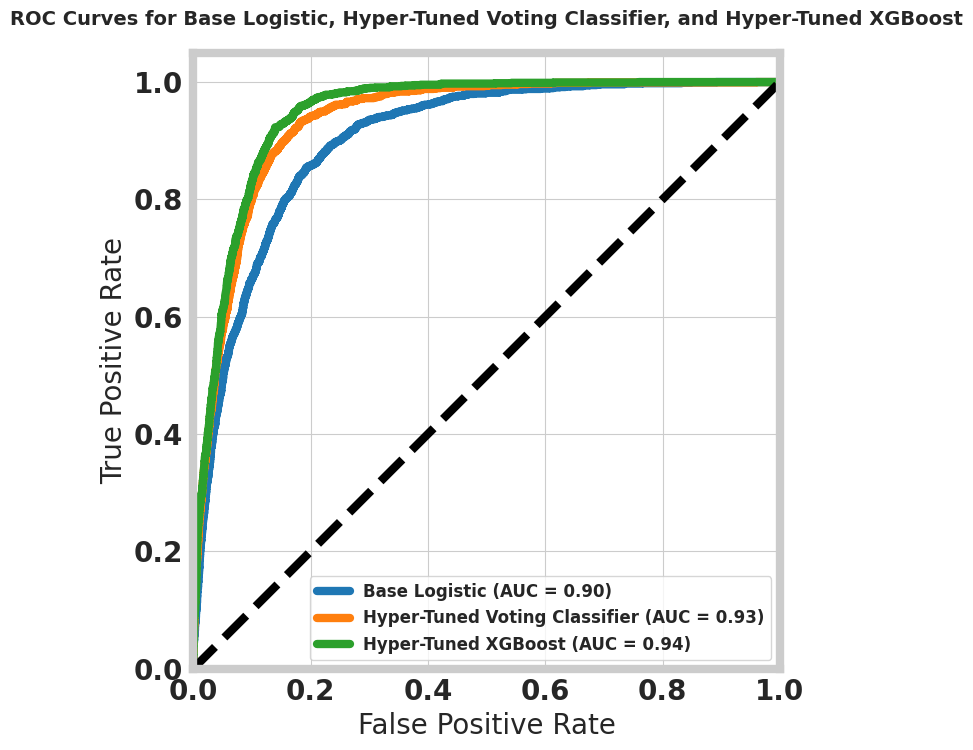

In [76]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Create a larger figure
fig, ax = plt.subplots(figsize=(12, 8))

# Base Logistic Model
RocCurveDisplay.from_estimator(logit, X_test_new, y_test, name='Base Logistic', ax=ax)

# Hyper-Tuned Voting Classifier
RocCurveDisplay.from_estimator(tuned_vc, X_test_new, y_test, name='Hyper-Tuned Voting Classifier', ax=ax)

# Hyper-Tuned XGBoost Model
RocCurveDisplay.from_estimator(best_xgb, X_test_new, y_test, name='Hyper-Tuned XGBoost', ax=ax)

# Plot diagonal line
ax.plot([0, 1], [0, 1], 'k--')

# Set limits and labels
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves for Base Logistic, Hyper-Tuned Voting Classifier, \
and Hyper-Tuned XGBoost', fontdict={'weight': 'bold', 'size': 14})

# Customize legend
ax.legend(loc='lower right', fontsize=12)

# Show plot
plt.show()



## Optimal Threshold Tuning

There are many techniques that are available to address imbalanced classes in machine learning classification problem, such as downsampling majority, upsampling minority (SMOTE) and use balanced weight while training models. Nevertheless, the most simplest yet overlooked approach is to change the decision threshold. The default decison threshold is 0.5. In his 2000 article titled “Machine Learning from Imbalanced Data Sets 101,” Foster Provost famously stated, “The bottom line is that when studying problems with imbalanced data, using the classifiers produced by standard machine learning algorithms without adjusting the output threshold may well be a critical mistake [3].”

### Example: Customer Subscription to Term Deposits

In a classification problem where we predict whether a customer will subscribe to a term deposit, the cost of misclassifying customers who do subscribe is high. Therefore, we want to minimize these misclassifications. In our dataset, the positive class (customers who subscribe) is a minority, comprising only 13%.

There are several reasons to consider an alternative to the default decision threshold:

1. **ROC Curves**: 
   - ROC curves help analyze the predicted probabilities of a model.
   - ROC AUC scores are used to compare and select models.
   - If you require crisp class labels, how do you choose the threshold on the ROC Curve that balances the true positive rate and the false positive rate?

2. **Precision-Recall Curves**:
   - Precision-recall curves analyze the predicted probabilities of a model.
   - Precision-recall AUC is used to compare and select models.
   - If you require crisp class labels, how do you choose the threshold on the Precision-Recall Curve that balances precision and recall?

3. **Probability-Based Metrics**:
   - Metrics like log loss (cross-entropy) are used to train, evaluate, and compare models.
   - If you require crisp class labels, how do you choose the optimal threshold from predicted probabilities?

4. **Cost Matrix**:
   - Different costs may be associated with false positive and false negative misclassifications.
   - You may use cost-insensitive models and later evaluate their predictions using a cost-sensitive measure.
   - How do you choose a threshold that finds the best trade-off for predictions using the cost matrix?


A popular way to train a cost-sensitive classifier without a known cost matrix is to modify the classification outputs when making predictions on new data. This is usually done by setting a threshold on the positive class, below which the negative class is predicted. The value of this threshold is optimized using a validation set, allowing the cost matrix to be learned from the training data.

The answer to these questions is to search a range of threshold values to find the best one. In some cases, the optimal threshold can be calculated directly.

Tuning or shifting the decision threshold to accommodate the broader requirements of the classification problem is generally referred to as “threshold-moving,” “threshold-tuning,” or simply “thresholding.”




## Optimal Threshold for Precision-Recall Curve

A precision-recall curve focuses on the performance of a classifier on the positive (minority) class.

- **Precision**: Ratio of true positives to the sum of true and false positives. It measures how well the model predicts the positive class.
- **Recall**: Ratio of true positives to the sum of true positives and false negatives. It is the same as sensitivity.

The precision-recall curve is created by calculating precision and recall for various thresholds (unique predict probabilities in test set) and plotting recall on the x-axis and precision on the y-axis. 

- **No-Skill Model**: Represented by a horizontal line at the precision level of the positive class ratio.
- **Perfect Skill Classifier**: Represented by a point in the top-right corner with full precision and recall.

Using the same model and dataset, we can evaluate a  selected model's probability predictions with a precision-recall curve. The `precision_recall_curve()` function calculates the curve, returning precision and recall scores for each threshold.


In [77]:
# Predict probabilities for the positive class
y_probs = best_xgb.predict_proba(X_test_new)[:, 1]

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Calculate f score for each threshold
f_score = 2 * precision * recall / (precision + recall)

# Filter out NaN values
valid_indices = ~np.isnan(f_score)
f_score_valid = f_score[valid_indices]
precision_valid = precision[valid_indices]
recall_valid = recall[valid_indices]

# Since thresholds has one less element, we need to adjust the valid_indices for thresholds
thresholds_valid = thresholds[valid_indices[:-1]]

# Find idx for maximum f-score
f_idxmax = f_score_valid.argmax()

# Find threshold corresponding to max f_score
optimized_threshold = thresholds_valid[f_idxmax]

# Training accuracy
test_predictions = (y_probs >= threshold).astype(int)
accuracy = accuracy_score(y_test, test_predictions)

# Print max f_score and optimized threshold
print(f"Maximized f_score: {f_score_valid.max()}")
print(f"Optimized precision: {precision_valid[f_idxmax]}")
print(f"Optimized recall: {recall_valid[f_idxmax]}")
print(f"Optimized threshold: {optimized_threshold}")
print(f"Test accuracy: {accuracy}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_probs)}")


Maximized f_score: 0.6366047745358091
Optimized precision: 0.5359535506922734
Optimized recall: 0.7838014369693012
Optimized threshold: 0.27529338002204895
Test accuracy: 0.7994556021481645
ROC-AUC: 0.9442921511229645


In [78]:
# Predict probabilities
probabilities = best_xgb.predict_proba(X_train_new)[:, 1]

# Apply threshold
threshold = optimized_threshold
predictions = (probabilities >= threshold).astype(int)

# Calculate metrics
train_precision = precision_score(y_train, predictions)
train_recall = recall_score(y_train, predictions)
train_f1 = f1_score(y_train, predictions)
train_accuracy = accuracy_score(y_train, predictions)

print(f'Precision: {train_precision}')
print(f'Recall: {train_recall}')
print(f'F1 Score: {train_f1}')
print(f'Accuracy: {train_accuracy}')


Precision: 0.5457364341085271
Recall: 0.792537793502734
F1 Score: 0.646379853095488
Accuracy: 0.9023011415111433


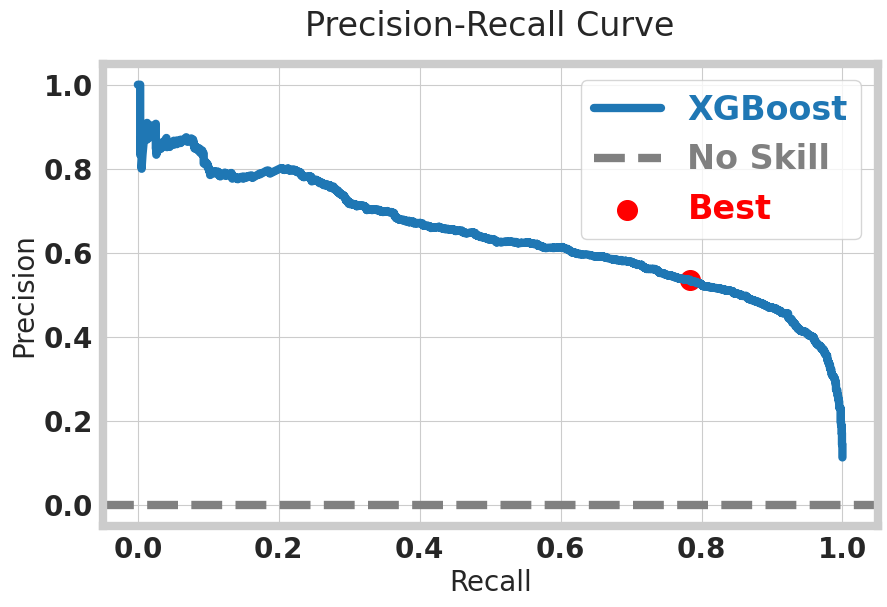

In [79]:
# Plot the precision-recall curve
plt.figure(figsize=(10, 6))
plt.plot(recall[valid_indices], precision[valid_indices], marker='.', label ='XGBoost')
plt.axhline(0, color = 'gray', linestyle = '--', label = 'No Skill')
plt.scatter(recall[f_idxmax], precision[f_idxmax], marker = 'o', color = 'red', s = 200, label = 'Best')
# Add labels and title
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(labelcolor = 'linecolor')
plt.grid(True)
plt.show()

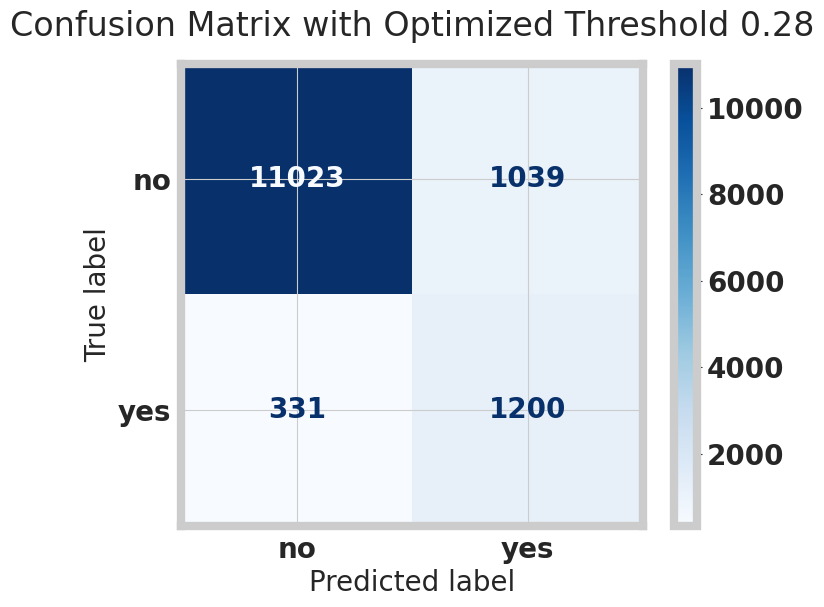

In [80]:
# Apply the optimized threshold to get crisp labels
y_pred_optimized = (y_probs >= optimized_threshold).astype(int)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_optimized)

# Create a figure with the desired size
fig, ax = plt.subplots(figsize=(8, 6))

# Display confusion matrix with custom labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title(f'Confusion Matrix with Optimized Threshold {optimized_threshold:.2f}')
plt.show()

## Neural Network

In [81]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from sklearn.metrics import make_scorer
from keras.layers import Dense
from keras.regularizers import l2
from keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD
from scikeras.wrappers import KerasClassifier

I0000 00:00:1777731932.868623    1435 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777731932.881325    1435 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777731933.882070    1435 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777731936.324981    1435 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [82]:
# convert to numpy arrays
X_train_np = X_train_new.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = X_test_new.to_numpy()
y_test_np = y_test.to_numpy()

To accomodate the class imbalance in the training set, we extract the number of yes and no to term deposit subscription using numpy `bincount` function.

In [83]:
counts = np.bincount(y_train_np)
counts

array([24486,  3109])

Below we use the reciprocal of each target class frequency to generate the weights of our model.

In [84]:
weight_for_0 = 1/counts[0]   # weight for no subscription
weight_for_1 = 1/counts[1]   # weight for yes subscription
weight_for_0, weight_for_1

(np.float64(4.0839663481172915e-05), np.float64(0.000321646831778707))

In [85]:
# Standardize the data
scaler = StandardScaler()

X_train_np = scaler.fit_transform(X_train_np)
X_test_np = scaler.transform(X_test_np)

We compile the model using adaptive moment estimation (adam) as gradient descent optimizer and binary cross-entropy as our loss function.

Lets define target class crisp labels and their corresponding weights as dictionary.

In [86]:
# class_weights = {
#     0: weight_for_0,
#     1: weight_for_1
# }

In [87]:
# optimized class_weights
class_weights = {0: 1, 1: 3}

# Define the model
model = Sequential([
    Dense(64, activation = 'relu', kernel_regularizer=l2(0.01)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1, activation='sigmoid')
])

# Compile the model with multiple metrics
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
fit_model = model.fit(
    X_train_np,
    y_train_np,
    batch_size = 512,
    epochs = 100,
    verbose = 0,
    validation_data=(X_test_np, y_test_np),
    class_weight=class_weights,
    callbacks=[early_stopping]
)

# Predict probabilities
y_pred_prob = model.predict(X_test_np)

# Find the best threshold
precision, recall, thresholds = precision_recall_curve(y_test_np, y_pred_prob)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]

# Apply the best threshold
y_pred = (y_pred_prob >= best_threshold).astype(int)

# Calculate the F1 score
f1 = f1_score(y_test_np, y_pred)
print(f'Best Threshold: {best_threshold}, F1 Score: {f1}')

E0000 00:00:1777732188.093616    1435 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Best Threshold: 0.5369930863380432, F1 Score: 0.5885111371629543
